<a href="https://colab.research.google.com/github/Yvonneamg/Modelling-the-epidemiologic-evolution-of-Diabetes-Mellitus-Integrating-Physiological-Agent-models/blob/main/FinalUpdatedHybridModeltodate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Load the required libraries**

In [145]:
# load the required libraries
!pip install jax jaxlib diffrax numpyro pyreadstat scipy matplotlib pandas
import scipy
import jax # For high performance numerical computing and automatic differentiation
import jax.numpy as jnp
import time
import scipy.stats
import jax.random as random
from jax import debug
from scipy import optimize
from scipy.stats import lognorm
from scipy.stats import multivariate_normal
from sklearn.metrics import roc_curve, auc
import pyreadstat
import pandas as pd # For data handling
import numpy as np # For data handling
from jax import jit, vmap
from jax.experimental.ode import odeint
from scipy.optimize import differential_evolution
from jax.scipy.special import logsumexp
import diffrax # For solving ODES
import math
from functools import partial
import matplotlib.pyplot as plt # For visualization
import matplotlib as mpl
from collections import defaultdict
import gc
import os
from datetime import datetime
import pickle
import numpyro # For probablistic modeling to be implemented later
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from numpyro.optim import Adam
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer import SVI, Trace_ELBO, init_to_median
from tqdm import tqdm
import optax
print("Setup complete!")

Setup complete!


#**Global Figure Saver**

In [146]:
# ============================================================================
# GLOBAL FIGURE SAVER
# ============================================================================

# Folder to store plots
PLOT_OUTPUT_DIR = "diabetes_plots"
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)

def save_figure(fig, name_prefix):
    """
    Save a matplotlib figure safely with timestamp.
    """

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    filename = f"{name_prefix}_{timestamp}.png"

    filepath = os.path.join(PLOT_OUTPUT_DIR, filename)

    fig.savefig(filepath, dpi=300, bbox_inches='tight')
    #plt.close(fig)

    print(f"Saved: {filename}")
    #return filepath

# **Reproduce De Gaetano Physiological Model.**

[5.0e+00 1.0e+03 3.5e+01 1.0e-03 1.0e-02 1.8e+01]
Simulation completed
Base:1.6670730113983154
Base:0.0010123252868652344
Base:0.0008418560028076172
Base:0.0007770061492919922
Saved: physiological_model_validation_20260514_215038.png


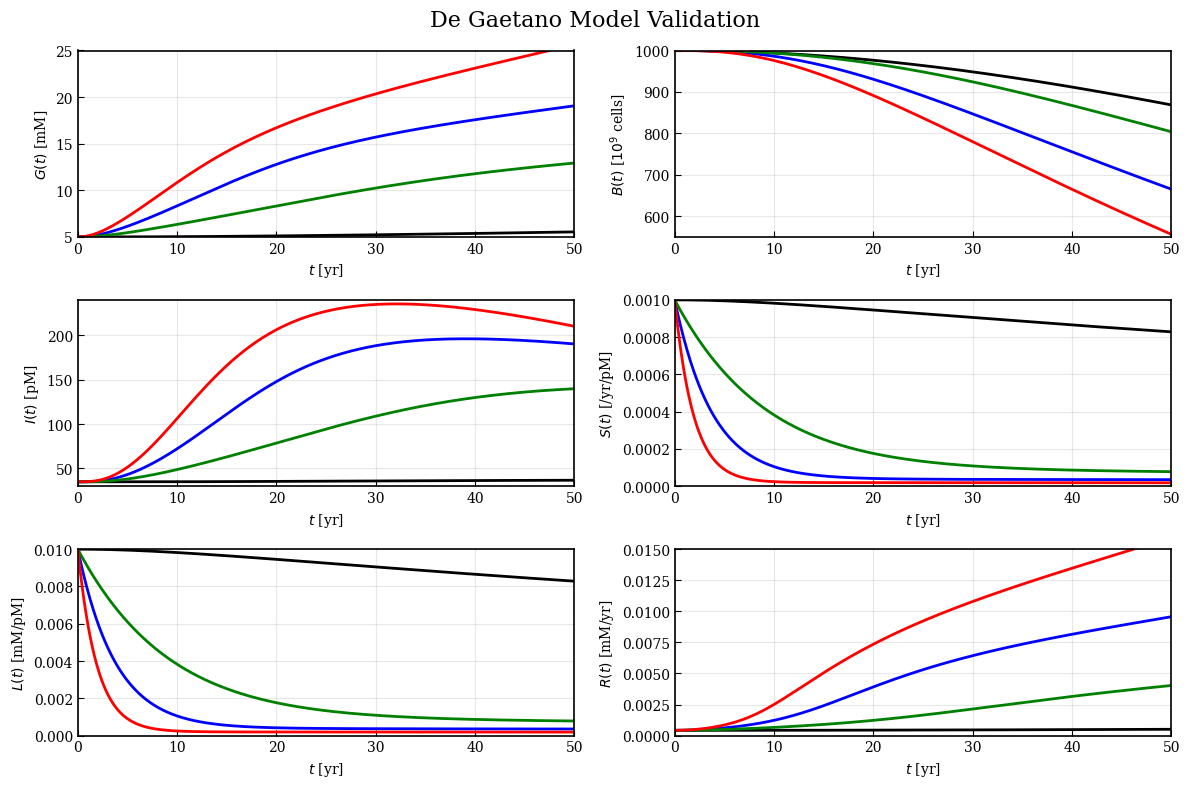

In [147]:
# =============================================================================
# PART 1: DE GAETANO PHYSIOLOGICAL MODEL
# =============================================================================

# Base parameters (Table 2)
params_base = {
    't0': 0, 'tend': 50, 't_delta': 0.1,
    'G0_N': 5.0, 'B_0': 1000.0, 'I0_N': 35.0,
    'S0_N': 0.001, 'L0_N': 0.01, 'R0': 0.000422144,
    'k_max_G': 1.00948, 'G_0': 5.0,
    'lambda_BA': 0.005, 'k_OB_G': 0.005, 'k_B': 25.0, 'B0_N': 1000.0,
    'k_OI': 0.5, 'gamma_IG': 2.0, 'G_I50': 20.0, 'k_max_I': 297.5, 'I_0': 35.0,
    'k_S': 0.0001, 'k_SY': 1e-09, 'k_OS': 0.1, 'k_OSF': 1e-05, 'k_OSA': 0.0005, 'S_0': 0.001,
    'k_L': 0.001, 'k_LY': 2e-09, 'k_OL': 0.1, 'k_OLF': 1e-05, 'k_OLA': 0.0005, 'L_0': 0.01,
    's_GR': 0.001, 'rho_GR': 0.5, 'G_R': 10.0, 'R0_N': 0.000422144,
    'F': 0.0, 'Y': 0.0, 'A0': 18.0
}


# Case parameters (Table 3)
params_cases = {}

for case in ['Black', 'Blue', 'Green', 'Red']:
    params_cases[case] = params_base.copy()

params_cases['Black'].update({
    'k_OB_G': 0.005, 'k_OS': 0.1, 'k_OL': 0.1,
    'k_B': 25.0, 'k_S': 0.0001, 'k_L': 0.001,
    'F': 0.0, 'k_OSF': 1e-05, 'k_OLF': 1e-5
})

params_cases['Blue'].update({
    'k_OB_G': 0.001, 'k_OS': 0.01, 'k_OL': 0.01,
    'k_B': 5.0, 'k_S': 1e-05, 'k_L': 0.0001,
    'F': 500.0, 'k_OSF': 0.0005, 'k_OLF': 0.0005
})

params_cases['Green'].update({
    'k_OB_G': 0.001, 'k_OS': 0.01, 'k_OL': 0.01,
    'k_B': 5.0, 'k_S': 1e-05, 'k_L': 0.0001,
    'F': 500.0, 'k_OSF': 0.0002, 'k_OLF': 0.0002
})

params_cases['Red'].update({
    'k_OB_G': 0.001, 'k_OS': 0.01, 'k_OL': 0.01,
    'k_B': 5.0, 'k_S': 1e-05, 'k_L': 0.0001,
    'F': 500.0, 'k_OSF': 0.001, 'k_OLF': 0.001
})

# Initial conditions (y0: [G, B, I, S, L, A]; B0=1000 Mc from Table 2)
A0=params_base['A0']
y0_base = jnp.array([params_base['G_0'], params_base['B_0'], params_base['I_0'], params_base['S_0'], params_base['L_0'],params_base['A0'] ])
print(y0_base)

# ODE RHS

def ode_rhs(t, y, params): #function ode_rhs that calculates how fast each body variable (like glucose or insulin) is changing at a specific moment t. It's the "rules" for how the system evolves, based on current states and settings.
    G, B, I, S, L, A = y #the array of state variables at time t
    F = params['F']
    Y = params['Y']

    # Eq 8: Renal R(G(t))
    discriminant = (4 * params['rho_GR'] * G) + ((G - params['G_R'] - params['rho_GR'])**2) # Calculates a helper number for the kidney function—it's part of smoothing out when kidneys start removing sugar (avoids sharp jumps).
    R = (params['s_GR'] / 2) * (jnp.sqrt(discriminant) + (G - params['G_R'] - params['rho_GR'])) # Computes the kidney sugar removal rate (R) using a square root formula. It's like a gentle ramp-up: low when glucose is normal, higher when it's elevated.

    # Eq1: dG/dt: Describes glucose dynamics. It's max liver sugar production (slowed by insulin and liver sensitivity) minus sugar used by body tissues minus kidney removal.
    dGdt = params['k_max_G'] * (jnp.exp(-(L * I * G))) - (S * I * G) - R

    # Eq2: dB/dt : Describes beta cell mass dynamics. It's a base growth rate (that fades with age) minus damage from high sugar.
    dBdt = params['k_B'] * (jnp.exp(-params['lambda_BA'] * (A - A0))) - (params['k_OB_G'] * G * B)

    # Eq3: dI/dt (Hill function): Describes insulin dynamics
    hill = G**params['gamma_IG'] / ((params['G_I50']**params['gamma_IG']) + (G**params['gamma_IG'])) # shows how insulin secretion ramps up with higher glucose—starts slow, then accelerates, like a sensitivity switch.
    dIdt = -(params['k_OI'] * I) + ((B / params['B0_N']) * params['k_max_I'] * hill) # it's minus natural breakdown plus production from beta cells (scaled by their number and the glucose trigger)

    # Eq4: dS/dt : Peripheral insulin sensitivity: Base recovery minus natural fade plus exercise boost minus penalty from extra food minus age-related drop
    dSdt = params['k_S'] - (params['k_OS'] * S) + (params['k_SY'] * Y) - (params['k_OSF'] * F * S) - (params['k_OSA'] * (A - A0) * S)

    # Eq5: dL/dt: Liver insulin sensitivity dynamics: Base recovery minus fade plus exercise minus food penalty minus age drop.
    dLdt = params['k_L'] - (params['k_OL'] * L )+ (params['k_LY'] * Y )- (params['k_OLF'] * F * L) - (params['k_OLA'] * (A - A0) * L)

    # Eq6: dA/dt: Age: Age just increases steadily by 1 year per year
    dAdt = 1.0

    return jnp.array([dGdt, dBdt, dIdt, dSdt, dLdt, dAdt])

#def ode_rhs_scan(y, t_span, opt_params, params, dt, y0): # Only introducing clipping and safe exponents to avoid Nans

    # Clip array of state variables at time t
    #G = jnp.clip(y[0], 1e-6, 1e3)
    #B = jnp.clip(y[1], 1e-6, 1e6)
    #I = jnp.clip(y[2], 1e-6, 1e4)
    #S = jnp.clip(y[3], 1e-6, 1e2)
    #L = jnp.clip(y[4], 1e-6, 1e2)
    #A = y[5]

    # Clip array of state variables at time t
    #G0 = jnp.clip(y0[0], 1e-6, 1e3)
    #B0 = jnp.clip(y0[1], 1e-6, 1e6)
    #I0 = jnp.clip(y0[2], 1e-6, 1e4)
    #S0 = jnp.clip(y0[3], 1e-6, 1e2)
    #L0 = jnp.clip(y0[4], 1e-6, 1e2)
    #A0 = y0[5]

    #lambda_BA,k_OB_G,k_OI,k_OSF,k_OSA,k_OLF,k_OLA = opt_params

    #F = params['F']
    #Y = params['Y']

    # introduce safe exponents
    #safe_exp_input_0 = jnp.clip(L0 * I0 * G0, -50, 50)
    #safe_exp_input = -jnp.clip(L * I * G, -50, 50)

    # kidney function
    #discriminant = (4 * params['rho_GR'] * G0) + ((G0 - params['G_R'] - params['rho_GR'])**2)
    #R0 = (params['s_GR'] / 2) * (jnp.sqrt(discriminant) + (G0 - params['G_R'] - params['rho_GR']))

    #discriminant = (4 * params['rho_GR'] * G) + ((G - params['G_R'] - params['rho_GR'])**2)
    #R = (params['s_GR'] / 2) * (jnp.sqrt(discriminant) + (G - params['G_R'] - params['rho_GR']))


    #k_max_G = jnp.exp(safe_exp_input_0) * (S0 * I0 * G0 + R0)

    #k_max_I = (k_OI * I0) / ((G0 ** params['gamma_IG']) / (params['G_I50'] ** params['gamma_IG'] + G0 ** params['gamma_IG']))

    #k_B = k_OB_G * G0 * B0
    #k_L = params['k_OL'] * L0 + k_OLF*F*L0
    #k_S = params['k_OS'] * S0 + k_OSF*F*S0

    # Safe dynamics
    #dGdt = k_max_G * jnp.exp(safe_exp_input) - (S * I * G) - R

    #dBdt = k_B * (jnp.exp(-lambda_BA * (A - A0))) - (k_OB_G * G * B)

    #hill = G**params['gamma_IG'] / ((params['G_I50']**params['gamma_IG']) + (G**params['gamma_IG']))
    #dIdt = -(k_OI * I) + ((B / B0) * k_max_I * hill)

    #dSdt = k_S - (params['k_OS'] * S) + (params['k_SY'] * Y) - (k_OSF * F * S) - (k_OSA * (A - A0) * S)

    #dLdt = k_L - (params['k_OL'] * L )+ (params['k_LY'] * Y )- (k_OLF * F * L) - (k_OLA * (A - A0) * L)

    #dAdt = 1.0

    #next_state = y + dt*jnp.array([dGdt, dBdt, dIdt, dSdt, dLdt, dAdt])

    #next_state = jnp.nan_to_num(next_state, nan=0.0, posinf=1e6, neginf=-1e6) # ensure simulation never breaks

    #return next_state, next_state


def ode_rhs_scan(y, t_span, opt_params , params, dt, y0):
    G, B, I, S, L, A = y #the array of state variables at time t
    G0, B0, I0, S0, L0, A0 = y0 #the array of state variables at time t
    lambda_BA,k_OB_G,k_OI,k_OSF,k_OSA,k_OLF,k_OLA = opt_params

    F = params['F']
    Y = params['Y']

    #Eq 8: Renal R(G(t))
    discriminant = (4 * params['rho_GR'] * G0) + ((G0 - params['G_R'] - params['rho_GR'])**2) # Calculates a helper number for the kidney function—it's part of smoothing out when kidneys start removing sugar (avoids sharp jumps).
    R0 = (params['s_GR'] / 2) * (jnp.sqrt(discriminant) + (G0 - params['G_R'] - params['rho_GR'])) # Computes the kidney sugar removal rate (R) using a square root formula. It's like a gentle ramp-up: low when glucose is normal, higher when it's elevated.

    discriminant = (4 * params['rho_GR'] * G) + ((G - params['G_R'] - params['rho_GR'])**2) # Calculates a helper number for the kidney function—it's part of smoothing out when kidneys start removing sugar (avoids sharp jumps).
    R = (params['s_GR'] / 2) * (jnp.sqrt(discriminant) + (G - params['G_R'] - params['rho_GR'])) # Computes the kidney sugar removal rate (R) using a square root formula. It's like a gentle ramp-up: low when glucose is normal, higher when it's elevated.

    #k_max_G = (jnp.exp(L0 * I0 * G0)) * (S0 * I0 * G0 + R0)
    #k_max_I = (k_OI * I0) / ((G0 ** params['gamma_IG']) / (params['G_I50'] ** params['gamma_IG'] + G0 ** params['gamma_IG']))
    #k_B = k_OB_G * G0 * B0
    #k_L = params['k_OL'] * L0 + k_OLF*F*L0
    #k_S = params['k_OS'] * S0 + k_OSF*F*S0

    #k_max_G = (jnp.exp(params['L0_N'] * params['I0_N'] * params['G0_N'])) * (params['S0_N'] * params['I0_N'] * params['G0_N'] + params['R0_N'])
    #k_max_I = (params['k_OI'] * params['I0_N']) / ((params['G0_N'] ** params['gamma_IG']) / (params['G_I50'] ** params['gamma_IG'] + params['G0_N'] ** params['gamma_IG']))
    #k_B = params['k_OB_G'] *  params['G0_N'] *  params['B0_N']
    #k_L = params['k_OL'] *  params['L0_N']
    #k_S = params['k_OS'] *  params['S0_N']

    k_max_G = params['k_max_G']
    k_max_I = params['k_max_I']
    k_B = params['k_B']
    k_L = params['k_L']
    k_S = params['k_S']

    # Eq1: dG/dt: Describes glucose dynamics. It's max liver sugar production (slowed by insulin and liver sensitivity) minus sugar used by body tissues minus kidney removal.
    dGdt = k_max_G * (jnp.exp(-(L * I * G))) - (S * I * G) - R

    # Eq2: dB/dt : Describes beta cell mass dynamics. It's a base growth rate (that fades with age) minus damage from high sugar.
    dBdt = k_B * (jnp.exp(-lambda_BA * (A - A0))) - (k_OB_G * G * B)

    # Eq3: dI/dt (Hill function): Describes insulin dynamics
    hill = G**params['gamma_IG'] / ((params['G_I50']**params['gamma_IG']) + (G**params['gamma_IG'])) # shows how insulin secretion ramps up with higher glucose—starts slow, then accelerates, like a sensitivity switch.
    dIdt = -(k_OI * I) + ((B / B0) * k_max_I * hill) # it's minus natural breakdown plus production from beta cells (scaled by their number and the glucose trigger)

    # Eq4: dS/dt : Peripheral insulin sensitivity: Base recovery minus natural fade plus exercise boost minus penalty from extra food minus age-related drop
    dSdt = k_S - (params['k_OS'] * S) + (params['k_SY'] * Y) - (k_OSF * F * S) - (k_OSA * (A - A0) * S)

    # Eq5: dL/dt: Liver insulin sensitivity dynamics: Base recovery minus fade plus exercise minus food penalty minus age drop.
    dLdt = k_L - (params['k_OL'] * L )+ (params['k_LY'] * Y )- (k_OLF * F * L) - (k_OLA * (A - A0) * L)

    # Eq6: dA/dt: Age: Age just increases steadily by 1 year per year
    dAdt = 1.0
    next_state = y + dt*jnp.array([dGdt, dBdt, dIdt, dSdt, dLdt, dAdt])
    return next_state, next_state
    #next_state = jax.nn.softplus((y + dt*jnp.array([dGdt, dBdt, dIdt, dSdt, dLdt, dAdt]))*100.0)/100.0
    #return next_state, next_state

# -----------------------------------------------------------------------------
# Euler solver
# -----------------------------------------------------------------------------
@jit
def solve_ode(params, t_span, y0):
    """Solve ODE with Diffrax"""
    def rhs(t, y, args): return ode_rhs(t, y, args) #A wrapper that calls the change-calculating function above.
    term = diffrax.ODETerm(rhs)
    solver = diffrax.Euler()
    sol = diffrax.diffeqsolve(term, solver, t0=t_span[0], t1=t_span[-1], dt0=0.1, y0=y0,args=params, saveat=diffrax.SaveAt(ts=t_span)) # Runs the solver: starts at time 0, goes to the end time, steps by 0.1 units, uses initial values y0, passes settings (params), and saves results at specific times in t_span.
    return sol.ys

t_span = jnp.linspace(0, 50, 1000)


print("Simulation completed")
#print("Solution shape:", sol.shape)



# PHYSIOLOGICAL MODEL VALIDATION PLOT

# R computation
def compute_R(G, params):
    discriminant = (4 * params['rho_GR'] * G) + ((G - params['G_R'] - params['rho_GR'])**2)
    R = (params['s_GR'] / 2) * (jnp.sqrt(discriminant) + (G - params['G_R'] - params['rho_GR']))
    return R

# Time span


# Figure and colors
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
fig.suptitle("De Gaetano Model Validation", fontsize=16, y=0.98)

colors = {
    'Black': 'black',
    'Blue': 'blue',
    'Green': 'green',
    'Red': 'red'
}

for case, color in colors.items():

    # Get parameters
    params = params_cases[case]

    y0 = jnp.array([
        params['G_0'],
        params['B_0'],
        params['I_0'],
        params['S_0'],
        params['L_0'],
        params['A0']
    ])

    # Solve model
    start_t = time.time()
    sol = solve_ode(params, t_span, y0)
    print("Base:"+str(time.time()-start_t))

    sol = np.array(sol)

    # Create age axis
    age = np.linspace(0, 50, len(sol))

    # Plot states
    axes[0,0].plot(age, sol[:,0], color=color, linewidth=2, label=case)
    axes[0,1].plot(age, sol[:,1], color=color, linewidth=2, label=case)
    axes[1,0].plot(age, sol[:,2], color=color, linewidth=2, label=case)
    axes[1,1].plot(age, sol[:,3], color=color, linewidth=2, label=case)
    axes[2,0].plot(age, sol[:,4], color=color, linewidth=2, label=case)

     # Compute R from G
    R_values = compute_R(sol[:,0], params)
    axes[2,1].plot(age, R_values, color=color, linewidth=2.0)  # R(t)


# =============================================================================
# AXIS LABELS
# =============================================================================

axes[0,0].set_ylabel(r"$G(t)$ [mM]")
axes[0,0].set_xlabel(r"$t$ [yr]")
axes[0,0].set_xlim(0,50)
axes[0,0].set_ylim(5,25)

axes[0,1].set_ylabel(r"$B(t)$ [$10^9$ cells]")
axes[0,1].set_xlabel(r"$t$ [yr]")
axes[0,1].set_xlim(0,50)
axes[0,1].set_ylim(550,1000)

axes[1,0].set_ylabel(r"$I(t)$ [pM]")
axes[1,0].set_xlabel(r"$t$ [yr]")
axes[1,0].set_xlim(0,50)
axes[1,0].set_ylim(30,240)

axes[1,1].set_ylabel(r"$S(t)$ [/yr/pM]")
axes[1,1].set_xlabel(r"$t$ [yr]")
axes[1,1].set_xlim(0,50)
axes[1,1].set_ylim(0.0000,0.0010)

axes[2,0].set_ylabel(r"$L(t)$ [mM/pM]")
axes[2,0].set_xlabel(r"$t$ [yr]")
axes[2,0].set_xlim(0,50)
axes[2,0].set_ylim(0.000,0.010)

axes[2,1].set_ylabel(r"$R(t)$ [mM/yr]")
axes[2,1].set_xlabel(r"$t$ [yr]")
axes[2,1].set_xlim(0,50)
axes[2,1].set_ylim(0.000,0.015)


# Grid
for ax in axes.flat:
    ax.grid(True, alpha=0.3)

# Layout
plt.tight_layout()

# Save figure using global saver
save_figure(fig, "physiological_model_validation")

# Show plot
plt.show()

##**Renal Glucose Elimination**

Saved: Renal glucose elimination_20260514_215039.png


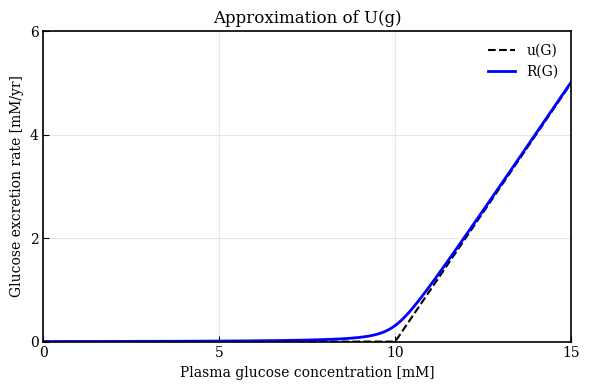

In [148]:
# The term  𝑅(𝐺(𝑡)) represents the average decrement of glucose concentration due to renal glucose elimination and to possible therapy with SGLT-2 inhibitors.
# Construction of equation 8
s_GR = 1.0  # mM/yr per mM (scale for linear elimination)
rho_GR = 0.01 # mM (smoothing factor)
G_R = 10.0  # mM (renal threshold)

# Glucose range (x-axis: 0 to 15 mM)
G = np.linspace(0, 15, 1000)

# Exact step function u(G) from Eq. (9)
u_G = np.where(G < G_R, 0, (s_GR * (G - G_R)))  # Piecewise: 0 below threshold, linear above

# Smooth approximation R(G) from Eq. (8)
discriminant = (4 * rho_GR * G) + ((G - G_R - rho_GR)**2)
R_G = (s_GR / 2) * (np.sqrt(discriminant) + (G - G_R - rho_GR))

# Plot dashed for u(G), solid blue for R(G)
plt.figure(figsize=(6, 4))
plt.plot(G, u_G, 'k--', linewidth=1.5, label='u(G)')  # Dashed black
plt.plot(G, R_G, 'b-', linewidth=2, label='R(G)')     # Solid blue
plt.xlabel('Plasma glucose concentration [mM]')
plt.ylabel('Glucose excretion rate [mM/yr]')
plt.xlim(0, 15)
plt.ylim(0, 6)
plt.xticks(np.arange(0, 16, 5))  # x-axis ticks: 0, 5, 10, 15
plt.yticks(np.arange(0, 7, 2))   # y-axis ticks: 0, 2, 4, 6
plt.grid(True, alpha=0.3)  # Light grid for readability
plt.legend()
plt.title('Approximation of U(g)')
plt.tight_layout()
save_figure(fig,"Renal glucose elimination")
plt.show()

# The smooth R(G) effectively approximates the biological renal threshold mechanism (where kidneys excrete excess glucose only above ~10 mM), no elimination in normoglycemia (G<10 mM), linear spillover in hyperglycemia

## **Simulation of impact of dietary changes**

Saved: Impact of dietary scenarios on model trajectories_20260514_215054.png


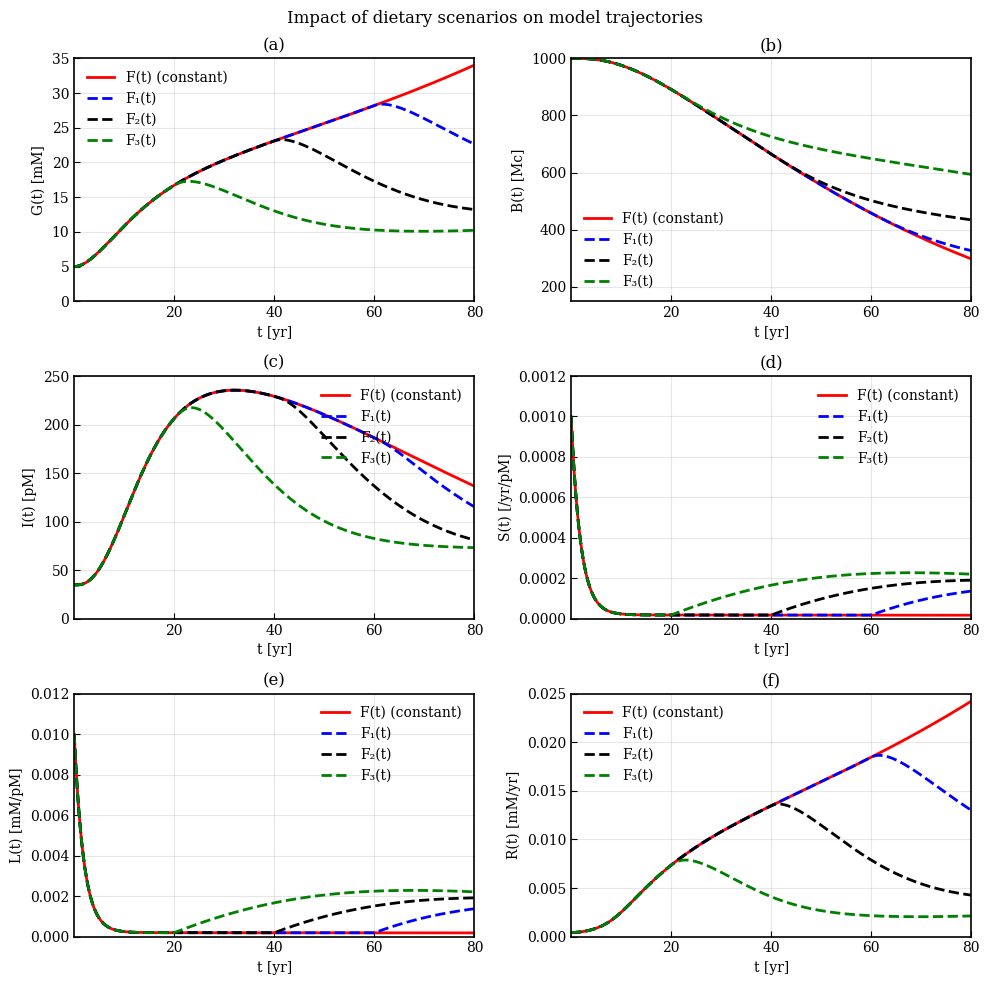

Red: Late-life avg G = 32.77 mM
F1: Late-life avg G = 24.08 mM
F2: Late-life avg G = 13.65 mM
F3: Late-life avg G = 10.15 mM


In [149]:
# Excess food intake effect

# Plot styling
mpl.rcParams.update({
    "text.usetex": False,    # LaTeX for all text
    "font.family": "serif",  # Serif font for paper style
    "axes.linewidth": 1.2,   # Thicker border lines
    "xtick.direction": "in", # Inward ticks
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "legend.frameon": False,  # No legend border
    "axes.facecolor": "white", # Clean white background
})

# Extend to t=80 yr (finer grid for smooth curves)
t_span = jnp.linspace(0, 80, 2000)
A0 = 18.0  # Starting age

# PARAMETERS
# Update "Red" params to include A0
params_red = params_cases['Red'].copy()
params_red['A0'] = A0
params_red['F'] = 500.0  # Excess level

# Initial conditions for Red case
y0_red = jnp.array([
    params_red['G_0'],    # G0
    params_red['B_0'],    # B0
    params_red['I_0'],    # I0
    params_red['S_0'],    # S0
    params_red['L_0'],    # L0
    A0                    # A0
])

# Scenarios dict: F_type as int (0=constant/inf, 1=60yr, 2=40yr, 3=20yr drop)
scenarios = {
    'Red': {'params': params_red, 'F_type': 0, 'color': 'red', 'style': '-', 'label': 'F(t) (constant)'},
    'F1': {'params': params_red, 'F_type': 1, 'color': 'blue', 'style': '--', 'label': 'F₁(t)'},
    'F2': {'params': params_red, 'F_type': 2, 'color': 'black', 'style': '--', 'label': 'F₂(t)'},
    'F3': {'params': params_red, 'F_type': 3, 'color': 'green', 'style': '--', 'label': 'F₃(t)'}
}

# ODE SYSTEM
# Updated ODE RHS: Inline thresh computation with JAX conditionals
def ode_rhs_timevar(t, y, args):
    params = args['params']
    F_type = args['F_type']
    G, B, I, S, L, A = y

    # Time-varying F: Chain jnp.where for branches
    # F_type 0: always 500 (thresh=inf)
    # F_type 1: 500 if t<60 else 0
    # F_type 2: 500 if t<40 else 0
    # F_type 3: 500 if t<20 else 0
    F = jnp.where(F_type == 0, params['F'],  # Constant
                  jnp.where(F_type == 1, jnp.where(t < 60.0, params['F'], 0.0),
                            jnp.where(F_type == 2, jnp.where(t < 40.0, params['F'], 0.0),
                                      jnp.where(F_type == 3, jnp.where(t < 20.0, params['F'], 0.0), 0.0))))  # Fallback 0
    Y = params['Y']  # Still 0


    # Renal R(G(t)) from Eq. 8
    discriminant = 4 * params['rho_GR'] * G + (G - params['G_R'] - params['rho_GR'])**2
    R = (params['s_GR'] / 2) * (jnp.sqrt(jnp.maximum(discriminant, 0.0)) + (G - params['G_R'] - params['rho_GR']))

    # Eq. 1: Glucose
    dGdt = params['k_max_G'] * jnp.exp(-L * I * G) - S * I * G - R

    # Eq. 2: Beta-cell mass
    dBdt = params['k_B'] * jnp.exp(-params['lambda_BA'] * (A - params['A0'])) - params['k_OB_G'] * G * B

    # Eq. 3: Insulin (Hill)
    hill = G**params['gamma_IG'] / (params['G_I50']**params['gamma_IG'] + G**params['gamma_IG'])
    dIdt = -params['k_OI'] * I + (B / params['B0_N']) * params['k_max_I'] * hill

    # Eq. 4: Peripheral sensitivity S
    dSdt = params['k_S'] - params['k_OS'] * S + params['k_SY'] * Y - params['k_OSF'] * F * S - params['k_OSA'] * (A - params['A0']) * S

    # Eq. 5: Central sensitivity L
    dLdt = params['k_L'] - params['k_OL'] * L + params['k_LY'] * Y - params['k_OLF'] * F * L - params['k_OLA'] * (A - params['A0']) * L

    # Eq. 6: Age
    dAdt = 1.0

    return jnp.array([dGdt, dBdt, dIdt, dSdt, dLdt, dAdt])

# Solve
def solve_ode_timevar(args, t_span, y0):
    # Direct lambda: Passes full args to ode_rhs_timevar
    vector_field = lambda t, y, _: ode_rhs_timevar(t, y, args)

    term = diffrax.ODETerm(vector_field)
    solver = diffrax.Euler()
    sol = diffrax.diffeqsolve(
        term, solver,
        t0=t_span[0], t1=t_span[-1],
        dt0=0.1, y0=y0,
        saveat=diffrax.SaveAt(ts=t_span)
    )
    return sol.ys  # Shape: (n_times, 6)


# Simulate all scenarios
solutions = {}
for name, info in scenarios.items():
    args = {'params': info['params'], 'F_type': info['F_type']}
    sol = solve_ode_timevar(args, t_span, y0_red)
    solutions[name] = sol

# Plot Fig. 5: 3x2 subplots
fig, axs = plt.subplots(3, 2, figsize=(10, 10))
age = t_span # Plot vs. age [yr]

for name, info in scenarios.items():
    sol = solutions[name]
    color, style, label = info['color'], info['style'], info['label']


    # print(f"{name} I min max: {sol[:,2].min()} {sol[:,2].max()}")  # Added to diagnose max I

    axs[0,0].plot(age, sol[:,0], color=color, linestyle=style, linewidth=2, label=label)

    axs[0,1].plot(age, sol[:,1], color=color, linestyle=style, linewidth=2, label=label)

    axs[1,0].plot(age, sol[:,2], color=color, linestyle=style, linewidth=2, label=label)

    axs[1,1].plot(age, sol[:,3], color=color, linestyle=style, linewidth=2, label=label)

    axs[2,0].plot(age, sol[:,4], color=color, linestyle=style, linewidth=2, label=label)

    R_vals = vmap(lambda g: compute_R(g, info['params']))(sol[:,0])
    axs[2,1].plot(age, R_vals, color=color, linestyle=style, linewidth=2, label=label)

# Formatting
axs[0,0].set_title('(a)')
axs[0,0].set_ylabel(r"G(t) [mM]")
axs[0,0].set_xlim(0, 80)
axs[0,0].set_ylim(0, 35)
axs[0,0].legend()

axs[0,1].set_title('(b)')
axs[0,1].set_ylabel(r"B(t) [Mc]")
axs[0,1].set_xlim(0, 80)
axs[0,1].set_ylim(150, 1000)
axs[0,1].legend()

axs[1,0].set_title('(c)')
axs[1,0].set_ylabel(r"I(t) [pM]")
axs[1,0].set_xlim(0, 80)
axs[1,0].set_ylim(0, 250)
axs[1,0].legend(loc='upper right')

axs[1,1].set_title('(d)')
axs[1,1].set_ylabel(r"S(t) [/yr/pM]")
axs[1,1].set_xlim(0, 80)
axs[1,1].set_ylim(0, 0.0012)
axs[1,1].legend()

axs[2,0].set_title('(e)')
axs[2,0].set_ylabel(r"L(t) [mM/pM]")
axs[2,0].set_xlim(0, 80)
axs[2,0].set_ylim(0, 0.012)
axs[2,0].legend()

axs[2,1].set_title('(f)')
axs[2,1].set_ylabel(r"R(t) [mM/yr]")
axs[2,1].set_xlim(0, 80)
axs[2,1].set_ylim(0, 0.025)
axs[2,1].legend()

for ax in axs.flat:
    ax.set_xlabel('t [yr]')
    ax.grid(True, alpha=0.3)
    ax.set_xticks([20, 40, 60, 80])  # Only show these tick marks

plt.suptitle("Impact of dietary scenarios on model trajectories")
plt.tight_layout()
save_figure(fig,"Impact of dietary scenarios on model trajectories")
plt.show()


# Print late-life averages
for name in scenarios:
    late_G = jnp.mean(solutions[name][-200:, 0])  # Avg G over last ~2 yr
    print(f"{name}: Late-life avg G = {late_G:.2f} mM")


# **NHANES data Processing**

In [150]:
# ============================================================================
# LOAD NHANES DATA FILES FROM GOOGLE DRIVE
# ============================================================================

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# File paths
file_path = "/content/drive/MyDrive/Colab Notebooks/PAXRAW_C.xpt"
demo_path = "/content/drive/MyDrive/Colab Notebooks/2003-2004/DEMO_C.xpt"
gluc_path = "/content/drive/MyDrive/Colab Notebooks/2003-2004/L10AM_C.xpt"
DR1TOT_C = "/content/drive/MyDrive/Colab Notebooks/Datasets/DR1TOT_C.xpt"

# Load datasets
demo_df = pd.read_sas(demo_path)
gluc_df = pd.read_sas(gluc_path)
dr1tot_df = pd.read_sas(DR1TOT_C)

# Quick verification
print("Datasets loaded successfully\n")


print("DEMO_C shape:", demo_df.shape)
print("GLUC_C shape:", gluc_df.shape)
print("DR1TOT_C shape:", dr1tot_df.shape)
#print("Glucose stats:", gluc_df["LBDGLUSI"].describe())
#print("Insulin stats:", gluc_df["LBDINSI"].describe())

cache_file = "nhanes_cached.pkl"
if os.path.exists(cache_file):

    print("Loading NHANES data from cache...")

    with open(cache_file, "rb") as f:
        data = pickle.load(f)

    print("Loaded cached dataset.")
    print("Rows:", len(data))

else:

    print("No cache found. Running full NHANES processing...")

    # Load demographic data
    demo, _ = pyreadstat.read_xport(
        demo_path,
        usecols=["SEQN", "WTMEC2YR", "RIDAGEYR", "RIAGENDR"]
    )

    # Load glucose / insulin data
    gluc, _ = pyreadstat.read_xport(gluc_path)

    # Load accelerometer data
    accel, _ = pyreadstat.read_xport(
        file_path,
        usecols=["SEQN", "PAXINTEN", "PAXSTAT", "PAXDAY"]
    )

    # Load dietary intake
    diet = pd.read_sas(DR1TOT_C)
    diet = diet[["SEQN", "DR1TKCAL"]]
    diet = diet[diet["DR1TKCAL"] > 0]


    # Merge datasets

    data = demo.copy()

    data = data.merge(gluc, on="SEQN", how="left")
    data = data.merge(diet, on="SEQN", how="left")

    # Process accelerometer data

    accel = accel[accel["PAXSTAT"] == 1]

    accel["intensity"] = pd.cut(
        accel["PAXINTEN"],
        bins=[-1, 99, 759, 2019, np.inf],
        labels=["sedentary", "light", "moderate", "vigorous"]
    )

    daily = (
        accel.groupby(["SEQN", "PAXDAY", "intensity"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )

    intensity_cols = ["sedentary", "light", "moderate", "vigorous"]

    for col in intensity_cols:
        if col not in daily.columns:
            daily[col] = 0

    daily["total_minutes"] = daily[intensity_cols].sum(axis=1)

    daily = daily[daily["total_minutes"] >= 600]

    person_activity = daily.groupby("SEQN")[intensity_cols + ["total_minutes"]].mean()

    person_activity["mvpa_minutes"] = (
        person_activity["moderate"] + person_activity["vigorous"]
    )

    data = data.merge(person_activity[["mvpa_minutes"]], on="SEQN", how="left")

    # Rename columns

    data = data.rename(
        columns={
            "RIDAGEYR": "age",
            "RIAGENDR": "gender",
            "WTMEC2YR": "weight",
            "DR1TKCAL": "calories",
            "LBDGLUSI": "glucose",
            "LBDINSI": "insulin"
        }
    )


    # Keep adults only

    data = data[data["age"] >= 18].copy()

    # ---------------------------------------------------------------------
    # Remove rows with missing required variables
    # ---------------------------------------------------------------------
    required_columns = ["age", "weight", "mvpa_minutes", "calories","glucose","insulin"]

    data = data.dropna(subset=required_columns)
    print("Datasets loaded successfully")

    # SAVE CACHE
    print("Saving processed dataset...")

    with open(cache_file, "wb") as f:
        pickle.dump(data, f)

    print("Cache saved:", cache_file)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Datasets loaded successfully

DEMO_C shape: (10122, 44)
GLUC_C shape: (3356, 7)
DR1TOT_C shape: (9643, 160)
Loading NHANES data from cache...
Loaded cached dataset.
Rows: 2084


In [151]:
# Cleaned data and summary

# Remove invalid weights, calories, mvpa_minutes
data = data[data["weight"] > 0]

data = data[(data["calories"] > 500) & (data["calories"] < 6000)] # ensure reasonable ranges

data = data[(data["mvpa_minutes"] >= 0) & (data["mvpa_minutes"] < 600)] # ensure reasonable ranges

print("Remaining individuals:", len(data))

print("Age range:", data["age"].min(), "-", data["age"].max())

print("Mean MVPA:", data["mvpa_minutes"].mean())

print("Mean calories:", data["calories"].mean())

data.head()


Remaining individuals: 2052
Age range: 18.0 - 85.0
Mean MVPA: 81.24647266313933
Mean calories: 2184.5375243664716


,SEQN,gender,age,weight,WTSAF2YR,LBXGLU,glucose,LBXCPSI,LBXIN,insulin,calories,mvpa_minutes
0,21005.0,1.0,19.0,5824.782465,14084.10,87.6,4.863,0.591,11.26,67.56,2984.0,102.428571
15,21020.0,2.0,55.0,29102.083555,65607.89,88.1,4.890,0.717,9.05,54.30,2575.0,30.571429
20,21025.0,2.0,18.0,13772.570375,33084.63,85.6,4.752,0.447,3.22,19.32,990.0,111.714286
24,21029.0,1.0,40.0,100099.630952,211685.72,92.9,5.157,0.987,11.02,66.12,4907.0,91.428571
28,21033.0,2.0,57.0,25488.344933,60329.07,96.3,5.346,0.919,11.52,69.12,1042.0,109.714286


##**Step 6: Fitting behavioral models**

Saved: age_trends_20260514_215104.png


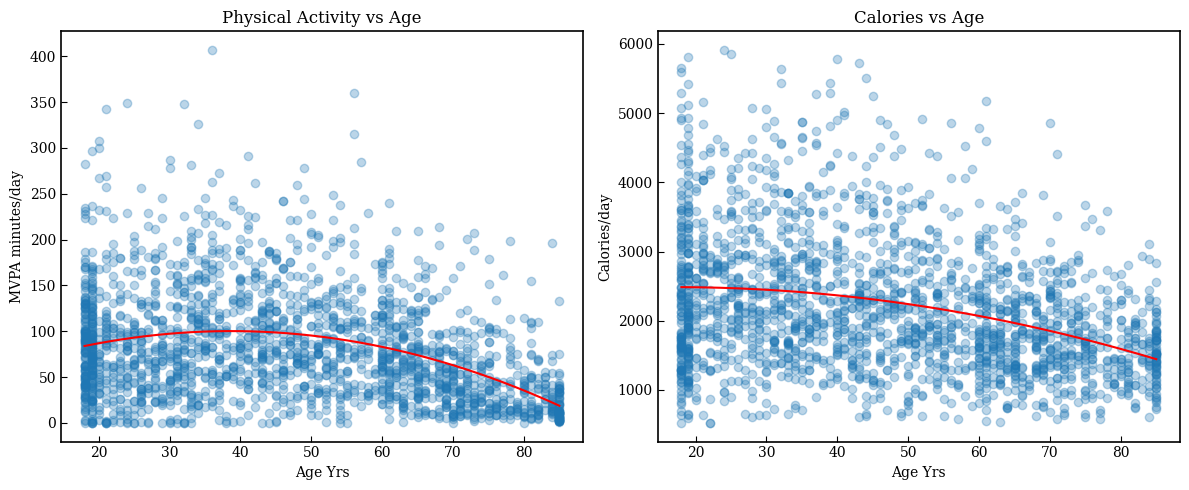

In [152]:
# AGE TRENDS: PHYSICAL ACTIVITY AND CALORIES VS AGE FOR THE WHOLE DATASET

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# MVPA vs Age

axes[0].scatter(data['age'], data['mvpa_minutes'], alpha=0.3)

mvpa_coeffs = np.polyfit(data['age'], data['mvpa_minutes'], 2)
mvpa_poly = np.poly1d(mvpa_coeffs)

x = np.linspace(data['age'].min(), data['age'].max(), 200)

axes[0].plot(x, mvpa_poly(x), color='red')

axes[0].set_title("Physical Activity vs Age")
axes[0].set_xlabel("Age Yrs")
axes[0].set_ylabel("MVPA minutes/day")

# Calories vs Age
axes[1].scatter(data['age'], data['calories'], alpha=0.3)

cal_coeffs = np.polyfit(data['age'], data['calories'], 2)
cal_poly = np.poly1d(cal_coeffs)

axes[1].plot(x, cal_poly(x), color='red')

axes[1].set_title("Calories vs Age")
axes[1].set_xlabel("Age Yrs")
axes[1].set_ylabel("Calories/day")

# Layout + Save
plt.tight_layout()
save_figure(fig, "age_trends")
plt.show()

Fitting behavioral models...

Behavior models fitted
MVPA polynomial coefficients: [-7.61531146e-04  6.24084275e-02  3.13605642e+00]
Calories polynomial coefficients: [-2.25155146e-01  7.64940956e+00  2.42041782e+03]
MVPA residual std: 0.928798228369071
Calories residual std: 904.1731316710991
length of data: 2052
Shape check:
F: (1000,) Y: (1000,)

Basic stats:
F -> min: 0.0 max: 2704.6123 mean: 328.5059
Y -> min: 1.6960418 max: 1510.4814 mean: 98.31364

Constant mode check:
Unique Y: [50.]
Unique F: [200.]

Calories below baseline → F should be 0:
Max F: 0.0

Determinism check:
F identical: False
Y identical: False

MVPA positivity check:
Any negative? False

Trend vs noisy output:
Mean of trend: 4.121200937781981
Mean of sampled: 4.1190157


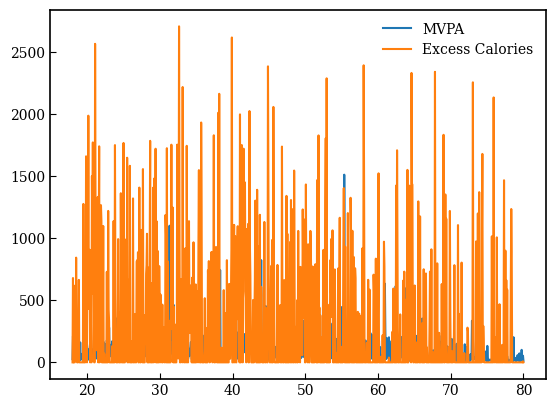

In [153]:
# =============================================================================
# FIT AGE-DEPENDENT BEHAVIORAL MODELS
# =============================================================================

print("Fitting behavioral models...")

# Fit quadratic polynomial trends

mvpa_coeffs = np.polyfit(data["age"],np.log(data["mvpa_minutes"] + 1),2) # Logtransform since mvpa is highly skewed, many small values few large values

calorie_coeffs = np.polyfit(data["age"],data["calories"],2)

# Create polynomial models

mvpa_poly = np.poly1d(mvpa_coeffs)
calorie_poly = np.poly1d(calorie_coeffs)


# Compute residual variability

mvpa_residuals = np.log(data["mvpa_minutes"] + 1) - mvpa_poly(data["age"])

calorie_residuals = data["calories"] - calorie_poly(data["age"])


mvpa_sigma = np.std(mvpa_residuals)

calorie_sigma = np.std(calorie_residuals)


print("\nBehavior models fitted")

print("MVPA polynomial coefficients:", mvpa_coeffs)

print("Calories polynomial coefficients:", calorie_coeffs)

print("MVPA residual std:", mvpa_sigma)

print("Calories residual std:", calorie_sigma)
print("length of data:",len(data))


# Store results for later use
behavior_models = {
    "mvpa_poly": mvpa_poly,
    "calorie_poly": calorie_poly,
    "mvpa_sigma": mvpa_sigma,
    "calorie_sigma": calorie_sigma
}


def generate_behavior_trajectories(age_grid, mvpa0, cal0, behavior_mode,key):
    """
    Generates F(t), Y(t) trajectories
    """

    if behavior_mode == "constant": # No behaviour change over life
        mvpa_traj = jnp.ones_like(age_grid) * mvpa0
        cal_traj  = jnp.ones_like(age_grid) * cal0

    elif behavior_mode == "dynamic":
        # age-dependent trends
        mvpa_mean = behavior_models["mvpa_poly"](age_grid)

        # SHIFT so it matches initial condition
        mvpa_mean = mvpa_mean - mvpa_mean[0] + jnp.log(mvpa0 + 1)
        cal_mean = behavior_models["calorie_poly"](age_grid)
        cal_mean = cal_mean - cal_mean[0] + cal0

        key1, key2 = jax.random.split(key)

        mvpa_traj = jnp.exp(
            mvpa_mean +
            behavior_models["mvpa_sigma"] *
            jax.random.normal(key1, shape=age_grid.shape)
        )

        cal_traj = (
            cal_mean +
            behavior_models["calorie_sigma"] *
            jax.random.normal(key2, shape=age_grid.shape)
        )

    # EXCESS CALORIES
    baseline = 2000.0
    F_traj = jnp.maximum(cal_traj - baseline, 0.0)

    Y_traj = mvpa_traj

    return F_traj, Y_traj

key = jax.random.PRNGKey(42)
# split keys for different calls
age_grid = jnp.linspace(18, 80, 1000)  # 10 points only

key, subkey = jax.random.split(key)
F, Y = generate_behavior_trajectories(age_grid, 50.0, 2200.0, "dynamic", subkey)

print("Shape check:")
print("F:", F.shape, "Y:", Y.shape)

print("\nBasic stats:")
print("F -> min:", F.min(), "max:", F.max(), "mean:", F.mean())
print("Y -> min:", Y.min(), "max:", Y.max(), "mean:", Y.mean())


# Constant mode does NOT need randomness
F_const, Y_const = generate_behavior_trajectories(age_grid, 50.0, 2200.0, "constant", key)

print("\nConstant mode check:")
print("Unique Y:", jnp.unique(Y_const))
print("Unique F:", jnp.unique(F_const))


F_low, _ = generate_behavior_trajectories(age_grid, 50.0, 1800.0, "constant", key)
print("\nCalories below baseline → F should be 0:")
print("Max F:", F_low.max())


#USE DIFFERENT KEYS → now stochastic works

key, subkey1 = jax.random.split(key)
key, subkey2 = jax.random.split(key)

F1, Y1 = generate_behavior_trajectories(age_grid, 50.0, 2200.0, "dynamic", subkey1)
F2, Y2 = generate_behavior_trajectories(age_grid, 50.0, 2200.0, "dynamic", subkey2)

print("\nDeterminism check:")
print("F identical:", jnp.allclose(F1, F2))
print("Y identical:", jnp.allclose(Y1, Y2))


print("\nMVPA positivity check:")
print("Any negative?", (Y < 0).any())


mvpa_mean = behavior_models["mvpa_poly"](age_grid)

print("\nTrend vs noisy output:")
print("Mean of trend:", mvpa_mean.mean())
print("Mean of sampled:", jnp.log(Y).mean())


plt.plot(age_grid, Y, label="MVPA")
plt.plot(age_grid, F, label="Excess Calories")
plt.legend()
plt.show()

Saved: residuals_20260514_215105.png


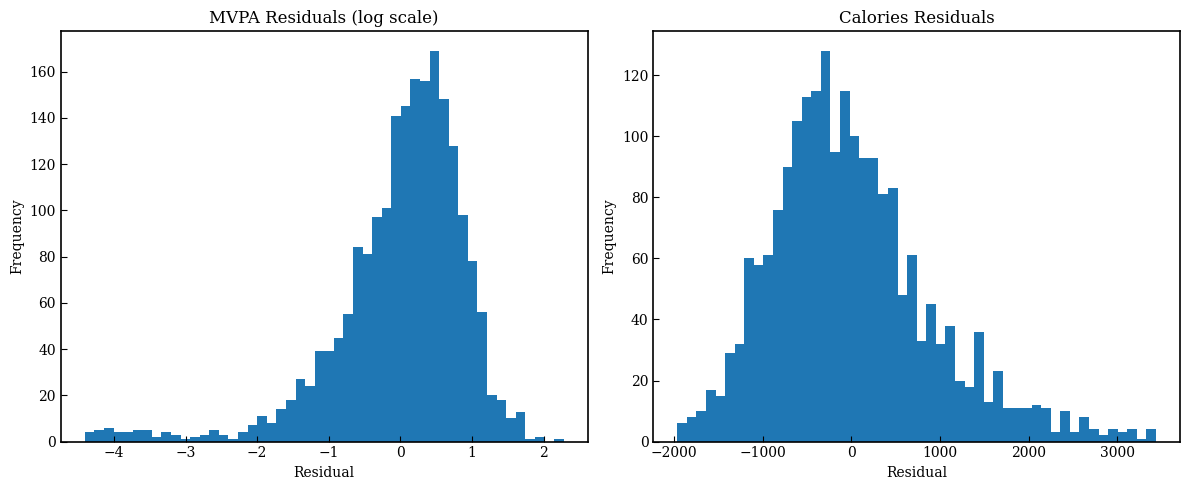

In [154]:
# RESIDUAL DISTRIBUTIONS

fig, axes = plt.subplots(1,2, figsize=(12,5))

# MVPA residuals
axes[0].hist(mvpa_residuals, bins=50)
axes[0].set_title("MVPA Residuals (log scale)")
axes[0].set_xlabel("Residual")
axes[0].set_ylabel("Frequency")

# Calories residuals
axes[1].hist(calorie_residuals, bins=50)
axes[1].set_title("Calories Residuals")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
save_figure(fig, "residuals")
plt.show()

## **Step 7: Build the initial conditions**

In [155]:
# =============================================================================
# BUILD INITIAL CONDITIONS FROM YOUNG NHANES INDIVIDUALS
# =============================================================================

n = 100   # number of individuals to sample

required_cols = [
    "age",
    "glucose",
    "insulin",
    "mvpa_minutes",
    "calories"
]

missing = [c for c in required_cols if c not in data.columns]

if missing:
    raise ValueError("Required NHANES columns missing: " + str(missing))


# Select young adults
young = data[(data["age"] >= 18) & (data["age"] <= 22)].copy()

if len(young) == 0:
    raise ValueError("No individuals aged 18–22 found")


# Remove rows with missing values
young = young.dropna(subset=required_cols)


if len(young) < n:
    raise ValueError(
        f"Requested {n} individuals but only {len(young)} have complete data"
    )


# Randomly sample individuals
sample = young.sample(n, random_state=42)

N_samples=100


# EMPIRICAL INITIALIZATION
empirical_subset = sample.sample(N_samples, random_state=42)

empirical_G0 = jnp.array(empirical_subset["glucose"].values)
empirical_I0 = jnp.array(empirical_subset["insulin"].values)
empirical_age = jnp.array(empirical_subset["age"].values)
empirical_mvpa = jnp.array(empirical_subset["mvpa_minutes"].values)
empirical_calories = jnp.array(empirical_subset["calories"].values)


# Build initial state vectors
initials = []

for _, row in sample.iterrows():

    A0 = float(row["age"])
    G0= float(row["glucose"])
    I0= float(row["insulin"])
    MVPA0 = float(row["mvpa_minutes"])
    CAL0 = float(row["calories"])


    initials.append([
        G0,     # Glucose
        I0,     # Insulin
        A0,     # Age
        MVPA0,  # Behavior (extra)
        CAL0    # Behavior (extra)
    ])


initials = np.array(initials)
initials_all=initials

print("\nYoung calibration cohort created")
print("Individuals:", len(initials))
print("Mean age:", np.mean(initials[:,2]))
print("Mean MVPA:", np.mean(initials[:,3]))
print("Mean calories:", np.mean(initials[:,4]))
print("Initials:",initials.shape)



Young calibration cohort created
Individuals: 100
Mean age: 19.13
Mean MVPA: 86.29857142857144
Mean calories: 2199.18
Initials: (100, 5)


In [156]:
# =============================================================================
# BUILD AGE-BINNED NHANES STATISTICS
# =============================================================================
data_filtered = data[(data["age"] >= 18) & (data["age"] <= 80)].copy()
bins = [10,20,30,40,50,60,70,80]
age_mid = np.array([15,25,35,45,55,65,75])
data_filtered["age_bin"] = pd.cut( data_filtered["age"], bins=bins, labels=age_mid )
grouped = ( data_filtered.groupby("age_bin", observed=True)[["glucose","insulin","mvpa_minutes","calories"]] .agg(["mean","std","count"]) .dropna() )
results = { "age_mid": age_mid, "G_mean": grouped["glucose"]["mean"].values, "G_sd": grouped["glucose"]["std"].values, "I_mean": grouped["insulin"]["mean"].values, "I_sd": grouped["insulin"]["std"].values, "mvpa_minutes_mean": grouped["mvpa_minutes"]["mean"].values, "mvpa_minutes_std": grouped["mvpa_minutes"]["std"].values, "calories_mean": grouped["calories"]["mean"].values, "calories_std": grouped["calories"]["std"].values, }

print("Age-binned statistics built")
print("Age midpoints:", results["age_mid"])
print("Mean glucose:", results["G_mean"])
print("Mean insulin:", results["I_mean"])
print("Mean mvpa:", results["mvpa_minutes_mean"])
print("Mean calories:", results["calories_mean"])

# STORE TARGET TRAJECTORIES
age_midpoints = results["age_mid"]
G_mean_target = results["G_mean"]
G_sd_target = results["G_sd"]
I_mean_target = results["I_mean"]
I_sd_target = results["I_sd"]
mvpa_minutes_mean_target = results["mvpa_minutes_mean"]
mvpa_minutes_sd_target = results["mvpa_minutes_std"]
calories_mean_target = results["calories_mean"]
calories_sd_target = results["calories_std"]
print("Target trajectories saved.")

Age-binned statistics built
Age midpoints: [15 25 35 45 55 65 75]
Mean glucose: [5.01482022 5.02229801 5.30031818 5.70978182 6.30467068 6.54505212
 6.26537198]
Mean insulin: [73.41191011 63.98602649 79.12422078 60.91221818 69.6253012  82.24495114
 66.62289855]
Mean mvpa: [ 86.94489032  86.92715232 103.45825603 100.70649351  91.46586345
  68.67612843  46.98481712]
Mean calories: [2379.89513109 2516.2218543  2519.16883117 2313.54545455 2113.53012048
 1871.96742671 1737.97101449]
Target trajectories saved.


Saved: age_binned_statistics plots_20260514_215106.png


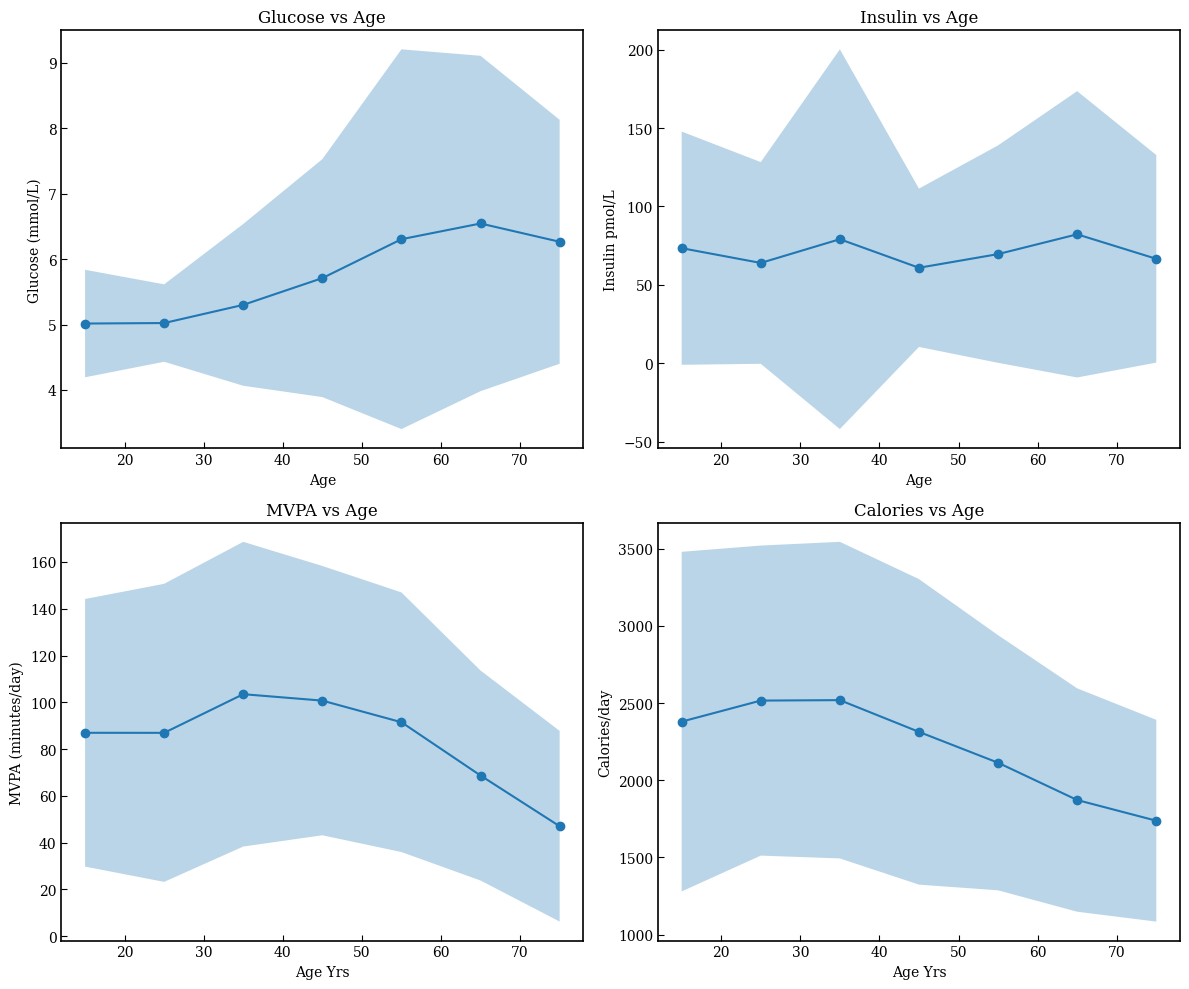

In [157]:
# =============================================================================
# AGE-BINNED MEAN ± STANDARD DEVIATION PLOTS
# =============================================================================

age = results["age_mid"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Glucose
axes[0,0].plot(age, results["G_mean"], marker='o')
axes[0,0].fill_between(
    age,
    results["G_mean"] - results["G_sd"],
    results["G_mean"] + results["G_sd"],
    alpha=0.3
)
axes[0,0].set_title("Glucose vs Age")
axes[0,0].set_xlabel("Age")
axes[0,0].set_ylabel("Glucose (mmol/L)")

# Insulin
axes[0,1].plot(age, results["I_mean"], marker='o')
axes[0,1].fill_between(
    age,
    results["I_mean"] - results["I_sd"],
    results["I_mean"] + results["I_sd"],
    alpha=0.3
)
axes[0,1].set_title("Insulin vs Age")
axes[0,1].set_xlabel("Age")
axes[0,1].set_ylabel("Insulin pmol/L")

# MVPA
axes[1,0].plot(age, results["mvpa_minutes_mean"], marker='o')
axes[1,0].fill_between(
    age,
    results["mvpa_minutes_mean"] - results["mvpa_minutes_std"],
    results["mvpa_minutes_mean"] + results["mvpa_minutes_std"],
    alpha=0.3
)
axes[1,0].set_title("MVPA vs Age")
axes[1,0].set_xlabel("Age Yrs")
axes[1,0].set_ylabel("MVPA (minutes/day)")

# Calories
axes[1,1].plot(age, results["calories_mean"], marker='o')
axes[1,1].fill_between(
    age,
    results["calories_mean"] - results["calories_std"],
    results["calories_mean"] + results["calories_std"],
    alpha=0.3
)
axes[1,1].set_title("Calories vs Age")
axes[1,1].set_xlabel("Age Yrs")
axes[1,1].set_ylabel("Calories/day")

# Final layout
plt.tight_layout()
save_figure(fig, "age_binned_statistics plots")
plt.show()

Age-binned statistics built
Saved: age_binned_percentile_plots_20260514_215107.png


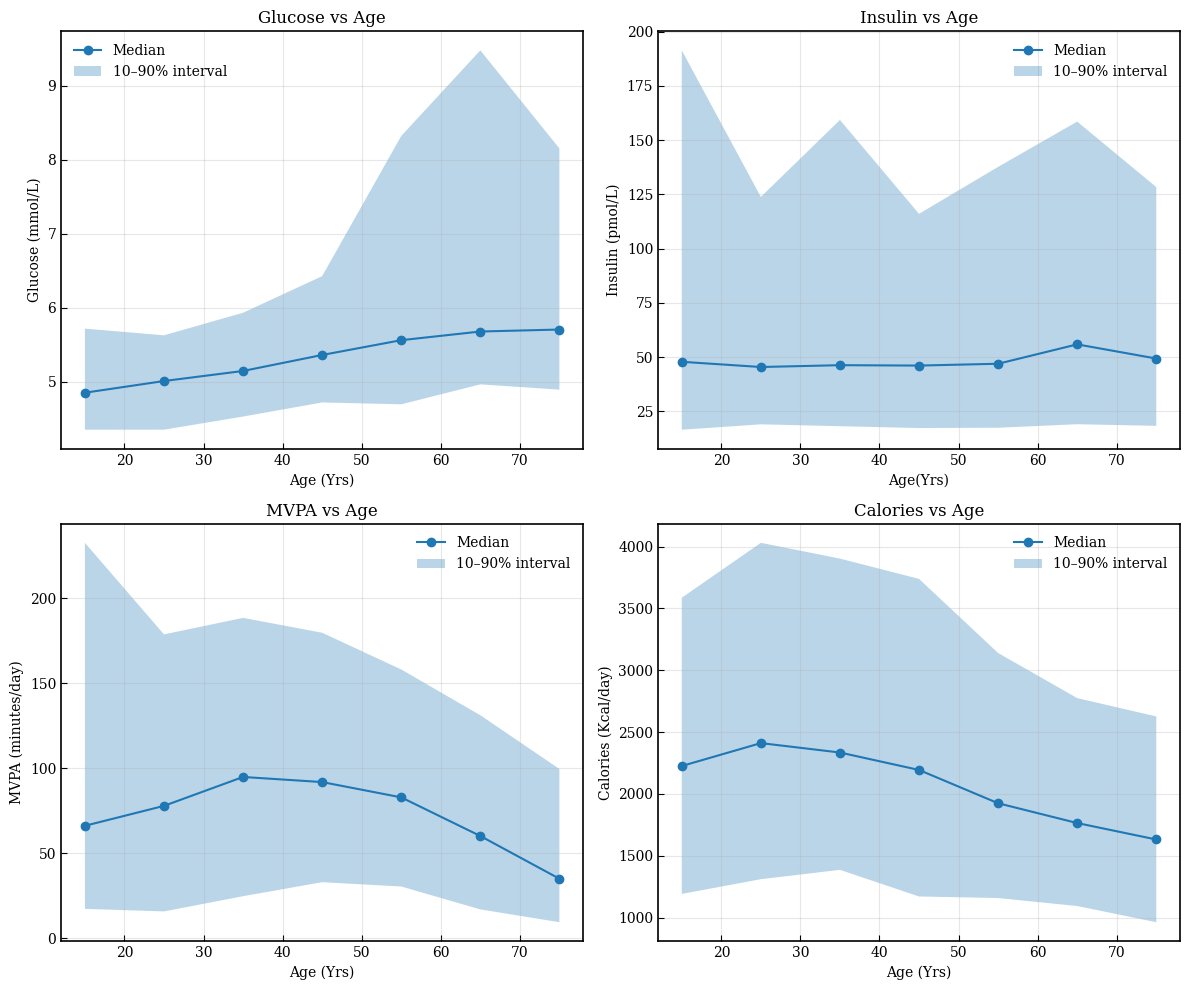

In [158]:
# =============================================================================
# BUILD AGE-BINNED NHANES STATISTICS
# =============================================================================
data_filtered = data[(data["age"] >= 20) & (data["age"] <= 80)].copy()
bins = [10,20,30,40,50,60,70,80]
age_mid = np.array([15,25,35,45,55,65,75])
data_filtered["age_bin"] = pd.cut( data_filtered["age"], bins=bins, labels=age_mid )

grouped = data_filtered.groupby("age_bin", observed=True)

results = {
    "age_mid": age_mid,

    "G_p10": grouped["glucose"].quantile(0.1).values,
    "G_p50": grouped["glucose"].quantile(0.5).values,
    "G_p90": grouped["glucose"].quantile(0.9).values,

    "I_p10": grouped["insulin"].quantile(0.1).values,
    "I_p50": grouped["insulin"].quantile(0.5).values,
    "I_p90": grouped["insulin"].quantile(0.9).values,

    "mvpa_p10": grouped["mvpa_minutes"].quantile(0.1).values,
    "mvpa_p50": grouped["mvpa_minutes"].quantile(0.5).values,
    "mvpa_p90": grouped["mvpa_minutes"].quantile(0.9).values,

    "cal_p10": grouped["calories"].quantile(0.1).values,
    "cal_p50": grouped["calories"].quantile(0.5).values,
    "cal_p90": grouped["calories"].quantile(0.9).values,
}

print("Age-binned statistics built")
age_midpoints = results["age_mid"]

# =============================================================================
# AGE-BINNED PERCENTILE PLOTS
# =============================================================================

age = results["age_mid"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# -------------------------
# Glucose
# -------------------------
axes[0,0].plot(age, results["G_p50"], marker='o', label="Median")
axes[0,0].fill_between(
    age,
    results["G_p10"],
    results["G_p90"],
    alpha=0.3,
    label="10–90% interval"
)
axes[0,0].set_title("Glucose vs Age")
axes[0,0].set_xlabel("Age (Yrs)")
axes[0,0].set_ylabel("Glucose (mmol/L)")
axes[0,0].grid(True, alpha=0.3)
axes[0,0].legend()

# -------------------------
# Insulin
# -------------------------
axes[0,1].plot(age, results["I_p50"], marker='o', label="Median")
axes[0,1].fill_between(
    age,
    results["I_p10"],
    results["I_p90"],
    alpha=0.3,
    label="10–90% interval"
)
axes[0,1].set_title("Insulin vs Age")
axes[0,1].set_xlabel("Age(Yrs)")
axes[0,1].set_ylabel("Insulin (pmol/L)")
axes[0,1].grid(True, alpha=0.3)
axes[0,1].legend()

# -------------------------
# MVPA
# -------------------------
axes[1,0].plot(age, results["mvpa_p50"], marker='o', label="Median")
axes[1,0].fill_between(
    age,
    results["mvpa_p10"],
    results["mvpa_p90"],
    alpha=0.3,
    label="10–90% interval"
)
axes[1,0].set_title("MVPA vs Age")
axes[1,0].set_xlabel("Age (Yrs)")
axes[1,0].set_ylabel("MVPA (minutes/day)")
axes[1,0].grid(True, alpha=0.3)
axes[1,0].legend()

# -------------------------
# Calories
# -------------------------
axes[1,1].plot(age, results["cal_p50"], marker='o', label="Median")
axes[1,1].fill_between(
    age,
    results["cal_p10"],
    results["cal_p90"],
    alpha=0.3,
    label="10–90% interval"
)
axes[1,1].set_title("Calories vs Age")
axes[1,1].set_xlabel("Age (Yrs)")
axes[1,1].set_ylabel("Calories (Kcal/day)")
axes[1,1].grid(True, alpha=0.3)
axes[1,1].legend()

# Layout
plt.tight_layout()
save_figure(fig, "age_binned_percentile_plots")
plt.show()

## **Fit a multivariate normal distribution to the (insulin, glucose) in the 18-22 age cohort**

In [159]:
# FIT MULTIVARIATE NORMAL (GLUCOSE, INSULIN)
glucose = young["glucose"].values
insulin = young["insulin"].values
print("Min insulin:", insulin.min())

#log_insulin = np.log(np.clip(insulin, 1e-6, None))
log_insulin = np.log(insulin)

data_pairs = np.column_stack((glucose, log_insulin))


# Fit Gaussian
mean = np.mean(data_pairs, axis=0)
cov = np.cov(data_pairs.T)

print(data_pairs.shape)
print("Fitted mean:", mean)
print("Fitted covariance:", cov)

Min insulin: 4.26
(333, 2)
Fitted mean: [5.0239009  3.92838834]
Fitted covariance: [[0.64853198 0.17334269]
 [0.17334269 0.68761548]]


Saved: Actual histogram of glucose insulin pairs_20260514_215108.png


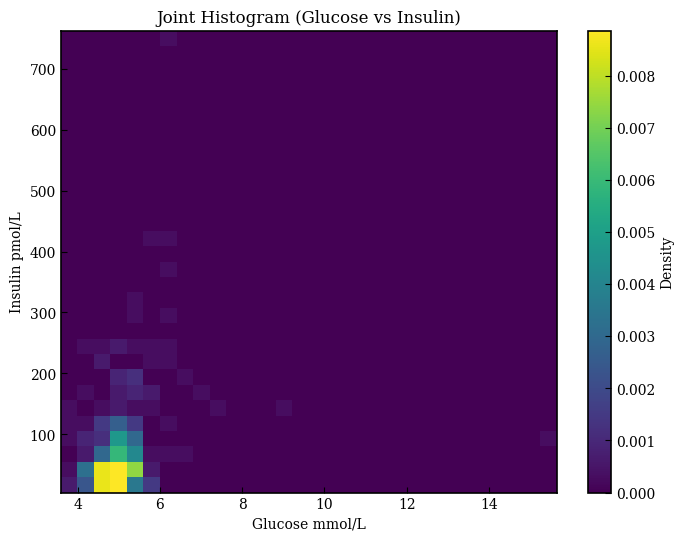

In [160]:
# ACTUAL HISTOGRAM OF (GLUCOSE, INSULIN) PAIRS
plt.figure(figsize=(8, 6))

plt.hist2d(glucose, insulin, bins=30, density=True)

plt.xlabel("Glucose mmol/L")
plt.ylabel("Insulin pmol/L")
plt.title("Joint Histogram (Glucose vs Insulin)")

#plt.yscale("log")  # Add log scale

plt.colorbar(label="Density")
fig = plt.gcf()
save_figure(fig, "Actual histogram of glucose insulin pairs")
plt.show()

Any NaNs in Z? False
Any infs in Z? False
Saved: Fitted Histogram and scatter gaussian distribution_20260514_215109.png


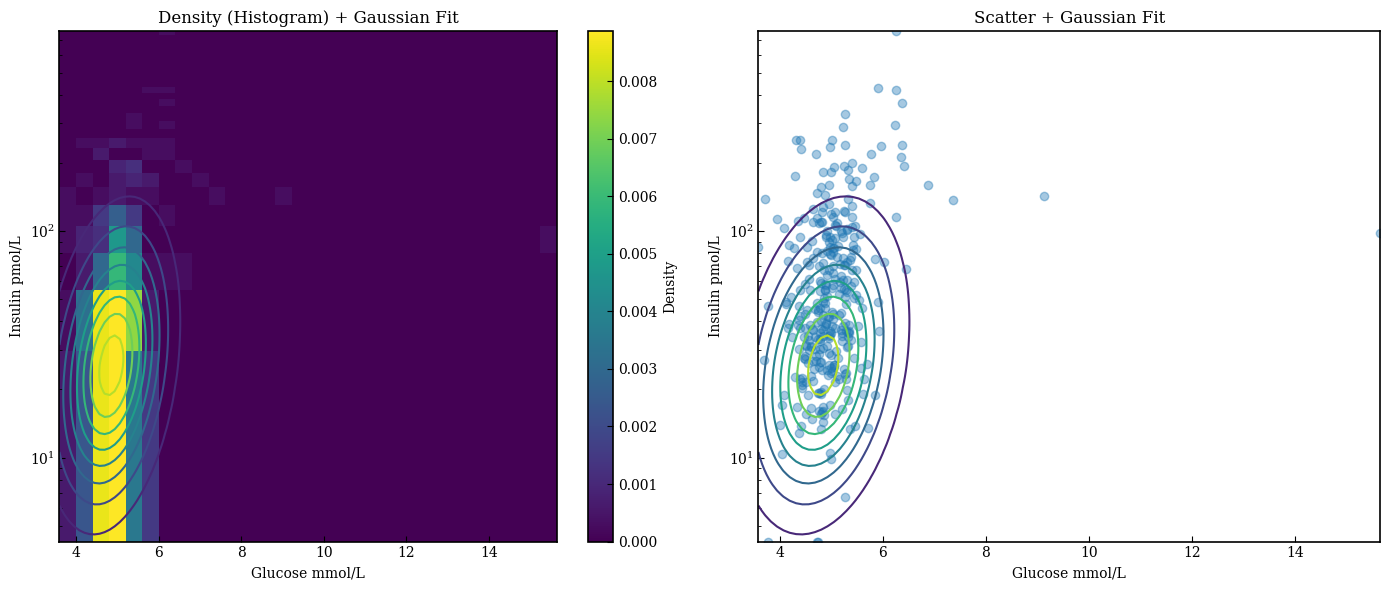

In [161]:
# Plots of fitted distribution

# Grid
x = np.linspace(glucose.min(), glucose.max(), 100)
y = np.logspace(np.log10(insulin.min()), np.log10(insulin.max()), 100)

X, Y = np.meshgrid(x, y)

# Log-transform insulin
#log_Y = np.log(np.clip(Y, 1e-6, None))
log_Y = np.log(Y)
pos = np.dstack((X, log_Y))

# Gaussian in (G, log I)
rv = multivariate_normal(mean, cov)
Z_log = rv.pdf(pos)

# Jacobian
Z = Z_log / Y
print("Any NaNs in Z?", np.isnan(Z).any())
print("Any infs in Z?", np.isinf(Z).any())
#Z = np.nan_to_num(Z, nan=0.0, posinf=0.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram
hist = axes[0].hist2d(glucose, insulin, bins=30, density=True)

axes[0].contour(X, Y, Z, levels=10)
axes[0].set_yscale("log")

axes[0].set_xlabel("Glucose mmol/L")
axes[0].set_ylabel("Insulin pmol/L")
axes[0].set_title("Density (Histogram) + Gaussian Fit")

fig.colorbar(hist[3], ax=axes[0], label="Density")

# Scatter
axes[1].scatter(glucose, insulin, alpha=0.4)
axes[1].contour(X, Y, Z, levels=10)
axes[1].set_yscale("log")

axes[1].set_xlabel("Glucose mmol/L")
axes[1].set_ylabel("Insulin pmol/L")
axes[1].set_title("Scatter + Gaussian Fit")

plt.tight_layout()
save_figure(fig, "Fitted Histogram and scatter gaussian distribution")
plt.show()

## **Defining Parameter Distributions over the model parameters**



  

In [162]:
print(params_cases["Red"])

# PARAM DISTRIBUTIONS
theta_keys = [
  "lambda_BA",
    "k_OB_G",
    "k_OI",
    "k_OSF",
    "k_OSA",
    "k_OLF",
    "k_OLA"
]

param_dist = {
    "lambda_BA": {"mu": params_cases["Red"]["lambda_BA"], "sigma": 0.003},
    "k_OB_G":    {"mu": params_cases["Red"]["k_OB_G"], "sigma": 0.003},
    "k_OI":      {"mu": params_cases["Red"]["k_OI"],  "sigma": 0.02},
    "k_OSF":     {"mu": params_cases["Red"]["k_OSF"], "sigma": 0.003},
    "k_OSA":     {"mu": params_cases["Red"]["k_OSA"], "sigma": 0.003},
    "k_OLF":     {"mu": params_cases["Red"]["k_OLF"], "sigma": 0.003},
    "k_OLA":     {"mu": params_cases["Red"]["k_OLA"], "sigma": 0.003}
}

print("Initial guesses distribution")
print(param_dist)

# MULTIVARIATE INIT DISTRIBUTION
# Convert already computed mean/cov to jax arrays
mean_jax = jnp.array(mean)     # shape (2,)
cov_jax = jnp.array(cov)       # shape (2,2)

# SAMPLING FUNCTION
def sample_parameters(key, param_dist, init_mean, init_cov, N):

    # SPLIT MAIN KEYS
    key_params, key_init, key_age, key_behavior = random.split(key, 4)

    # SAMPLE AGE
    ages = random.choice(
        key_age,
        jnp.array(young["age"]),
        shape=(N,)
    )

    # SAMPLE BEHAVIOR
    mvpa_mean = behavior_models["mvpa_poly"](ages)

    key_mvpa, key_cal = random.split(key_behavior)

    mvpa = jnp.exp(
        mvpa_mean +
        behavior_models["mvpa_sigma"] *
        random.normal(key_mvpa, shape=(N,))
    )

    calories = (
        behavior_models["calorie_poly"](ages) +
        behavior_models["calorie_sigma"] *
        random.normal(key_cal, shape=(N,))
    )

    # SPLIT KEYS FOR LOOP
    keys = random.split(key_params, N)

    samples = []
    matrix_samples = []

    for i in range(N):
        subkey = keys[i]
        sample = {}

        # Split key for params + multivariate
        subkeys = random.split(subkey, len(param_dist) + 1)

        vector_samples = []

        # PARAMS
        for j, (name, dist) in enumerate(param_dist.items()):
            val = random.normal(subkeys[j]) * dist["sigma"] + dist["mu"]
            sample[name] = val
            vector_samples.append(val)

        # MULTIVARIATE (G0, I0)
        gi_sample = random.multivariate_normal(
            subkeys[-1],
            mean=init_mean,
            cov=init_cov
        )

        sample["G0"] = gi_sample[0]
        sample["I0"] = jnp.exp(gi_sample[1])

        vector_samples.append(sample["G0"])
        vector_samples.append(sample["I0"])

        # ADD AGE + BEHAVIOR
        sample["age"] = ages[i]
        sample["mvpa"] = mvpa[i]
        sample["calories"] = calories[i]

        vector_samples.append(sample["age"])
        vector_samples.append(sample["mvpa"])
        vector_samples.append(sample["calories"])

        samples.append(sample)
        matrix_samples.append(jnp.array(vector_samples))

    return samples, jnp.stack(matrix_samples)

key = random.PRNGKey(0)

N = 100

samples, vectorized_samples = sample_parameters(
    key,
    param_dist,
    mean_jax,
    cov_jax,
    N
)

print(len(samples))
print(samples[0])
print(vectorized_samples.shape)
print(vectorized_samples[:,-2])
print(vectorized_samples[:,-1])

{'t0': 0, 'tend': 50, 't_delta': 0.1, 'G0_N': 5.0, 'B_0': 1000.0, 'I0_N': 35.0, 'S0_N': 0.001, 'L0_N': 0.01, 'R0': 0.000422144, 'k_max_G': 1.00948, 'G_0': 5.0, 'lambda_BA': 0.005, 'k_OB_G': 0.001, 'k_B': 5.0, 'B0_N': 1000.0, 'k_OI': 0.5, 'gamma_IG': 2.0, 'G_I50': 20.0, 'k_max_I': 297.5, 'I_0': 35.0, 'k_S': 1e-05, 'k_SY': 1e-09, 'k_OS': 0.01, 'k_OSF': 0.001, 'k_OSA': 0.0005, 'S_0': 0.001, 'k_L': 0.0001, 'k_LY': 2e-09, 'k_OL': 0.01, 'k_OLF': 0.001, 'k_OLA': 0.0005, 'L_0': 0.01, 's_GR': 0.001, 'rho_GR': 0.5, 'G_R': 10.0, 'R0_N': 0.000422144, 'F': 500.0, 'Y': 0.0, 'A0': 18.0}
Initial guesses distribution
{'lambda_BA': {'mu': 0.005, 'sigma': 0.003}, 'k_OB_G': {'mu': 0.001, 'sigma': 0.003}, 'k_OI': {'mu': 0.5, 'sigma': 0.02}, 'k_OSF': {'mu': 0.001, 'sigma': 0.003}, 'k_OSA': {'mu': 0.0005, 'sigma': 0.003}, 'k_OLF': {'mu': 0.001, 'sigma': 0.003}, 'k_OLA': {'mu': 0.0005, 'sigma': 0.003}}
100
{'lambda_BA': Array(0.00061126, dtype=float32), 'k_OB_G': Array(-0.0031633, dtype=float32), 'k_OI': Arra

##**Reparametrization Trick for Model Parameters**

In [163]:
mus = jnp.array([param_dist[k]["mu"] for k in theta_keys])
sigmas = jnp.array([param_dist[k]["sigma"] for k in theta_keys])
def reparameterized_sample(mus, sigmas, eps): # sample from log_normal distribution making sampling differentiable
    return jnp.exp(jnp.log(mus) + sigmas * eps)

def build_params(param_sample):# take a sampled parameter vector and convert to a dictionary for the solver
    return {
        #**params_base,
        **params_cases["Red"],
        "lambda_BA": param_sample[0],
        "k_OB_G":    param_sample[1],
        "k_OI":      param_sample[2],
        "k_OSF":     param_sample[3],
        "k_OSA":     param_sample[4],
        "k_OLF":     param_sample[5],
        "k_OLA":     param_sample[6],
    }
key = jax.random.PRNGKey(0) #jax random seed

N_samples = 100  # keep small initially

# noise for reparameterization
key, subkey = jax.random.split(key)
eps = jax.random.normal(subkey, shape=(N_samples, 7))

param_samples = vmap(reparameterized_sample, in_axes=(None, None, 0))(mus, sigmas, eps)
print(param_samples.shape)

(100, 7)


In [164]:
print(params_cases["Red"])

{'t0': 0, 'tend': 50, 't_delta': 0.1, 'G0_N': 5.0, 'B_0': 1000.0, 'I0_N': 35.0, 'S0_N': 0.001, 'L0_N': 0.01, 'R0': 0.000422144, 'k_max_G': 1.00948, 'G_0': 5.0, 'lambda_BA': 0.005, 'k_OB_G': 0.001, 'k_B': 5.0, 'B0_N': 1000.0, 'k_OI': 0.5, 'gamma_IG': 2.0, 'G_I50': 20.0, 'k_max_I': 297.5, 'I_0': 35.0, 'k_S': 1e-05, 'k_SY': 1e-09, 'k_OS': 0.01, 'k_OSF': 0.001, 'k_OSA': 0.0005, 'S_0': 0.001, 'k_L': 0.0001, 'k_LY': 2e-09, 'k_OL': 0.01, 'k_OLF': 0.001, 'k_OLA': 0.0005, 'L_0': 0.01, 's_GR': 0.001, 'rho_GR': 0.5, 'G_R': 10.0, 'R0_N': 0.000422144, 'F': 500.0, 'Y': 0.0, 'A0': 18.0}


## **Simulate Samples**

In [165]:
# Simulate samples
# ================================
N_samples = 100
key = jax.random.PRNGKey(42)

t_span = jnp.linspace(18, 80, 1000)
dt = t_span[1] - t_span[0]

# INITIAL STATE BUILDER

def build_initial_states(G0, I0, A0):
    return jnp.column_stack([
        G0,
        jnp.full_like(G0, params_cases["Red"]['B_0']),
        I0,
        jnp.full_like(G0, params_cases["Red"]['S_0']),
        jnp.full_like(G0, params_cases["Red"]['L_0']),
        A0
    ])

# INITIAL CONDITIONS

init_baseline = build_initial_states(
    vectorized_samples[:, -5],
    vectorized_samples[:, -4],
    vectorized_samples[:, -3]
)

init_distribution = build_initial_states(
    vectorized_samples[:, -5],
    vectorized_samples[:, -4],
    vectorized_samples[:, -3]
)

init_empirical = build_initial_states(
    empirical_G0,
    empirical_I0,
    empirical_age
)

# PARAMETER SAMPLING

key, subkey = jax.random.split(key)

eps = jax.random.normal(subkey, shape=(N_samples, 7))

param_samples = jax.vmap(
    reparameterized_sample,
    in_axes=(None, None, 0)
)(mus, sigmas, eps)

# SIMULATION FUNCTION

def simulate_population(init_states, mvpa0, cal0, behavior_mode, key):

    key, subkey = jax.random.split(key)
    keys = jax.random.split(subkey, N_samples)

    def simulate_one(param_ind, init_ind, mvpa_i, cal_i, key_i):

        # --- behavior ---
        F_traj, Y_traj = generate_behavior_trajectories(
            t_span,
            mvpa_i,
            cal_i,
            behavior_mode,
            key_i
        )

        # --- base parameters ---
        base_params = dict(params_cases["Red"])
        for i, name in enumerate(theta_keys):
            base_params[name] = param_ind[i]

        # --- scan step ---
        def step(y, inputs):
            t, F_t, Y_t = inputs

            params_step = {**base_params, "F": F_t, "Y": Y_t}

            y_next, _ = ode_rhs_scan(
                y, t, param_ind, params_step, dt, init_ind
            )
            return y_next, y_next

        _, ys = jax.lax.scan(
            step,
            init_ind,
            (t_span, F_traj, Y_traj)
        )

        return ys

    states = jax.vmap(simulate_one)(
        param_samples,
        init_states,
        mvpa0,
        cal0,
        keys
    )

    return states

# BEHAVIOR INPUTS
mvpa_samples = vectorized_samples[:, -2]
calorie_samples = vectorized_samples[:, -1]

# RUN ALL SCENARIOS
results = {}

for init_name, init_states in {
    "baseline": init_baseline,
    "distribution": init_distribution,
    "empirical": init_empirical
}.items():

    # ONE key per cohort (shared across scenarios)
    key, subkey = jax.random.split(key)

    for behavior_mode in ["constant", "dynamic"]:

        states = simulate_population(
            init_states,
            mvpa_samples,
            calorie_samples,
            behavior_mode,
            subkey   # SAME key
        )
        results[(init_name, behavior_mode)] = states

        print(f"{init_name} + {behavior_mode} → shape:", states.shape)


# SANITY CHECK

for (init_name, behavior_mode), states in results.items():

    G_all = states[:, :, 0]   # glucose trajectories
    I_all = states[:, :, 2]   # insulin trajectories

    for i in range(G_all.shape[0]):

        if jnp.isnan(G_all[i]).any():
            print(f"NaN in G | {init_name} + {behavior_mode} | trajectory {i}")

        if jnp.isinf(G_all[i]).any():
            print(f"Inf in G | {init_name} + {behavior_mode} | trajectory {i}")

        if jnp.isnan(I_all[i]).any():
            print(f"NaN in I | {init_name} + {behavior_mode} | trajectory {i}")

        if jnp.isinf(I_all[i]).any():
            print(f"Inf in I | {init_name} + {behavior_mode} | trajectory {i}")

# EXAMPLE: EXTRACT ONE CASE
states_dynamic_emp = results[("empirical", "dynamic")]

G = states_dynamic_emp[:, :, 0]
I = states_dynamic_emp[:, :, 2]

print("G shape:", G.shape)
print("I shape:", I.shape)

baseline + constant → shape: (100, 1000, 6)
baseline + dynamic → shape: (100, 1000, 6)
distribution + constant → shape: (100, 1000, 6)
distribution + dynamic → shape: (100, 1000, 6)
empirical + constant → shape: (100, 1000, 6)
empirical + dynamic → shape: (100, 1000, 6)
G shape: (100, 1000)
I shape: (100, 1000)


In [166]:
# =============================================================================
# DEBUG + SANITY CHECK + PLOTTING (ALL SCENARIOS)
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# SANITY CHECK: NaN / Inf detection across all scenarios
# -----------------------------------------------------------------------------
print("\n===== SANITY CHECK =====")

state_names = ["G", "B", "I", "S", "L", "A"]

for (init_name, behavior_mode), states in results.items():

    print(f"\n--- {init_name} + {behavior_mode} ---")

    for idx, name in enumerate(state_names):
        traj = states[:, :, idx]

        nan_count = jnp.isnan(traj).any(axis=1).sum()
        inf_count = jnp.isinf(traj).any(axis=1).sum()

        print(f"{name}: NaNs={nan_count}, Infs={inf_count}")

    # Detailed inspection for glucose (G)
    G = states[:, :, 0]
    nanidx = np.argwhere(jnp.isnan(G[:, -1]))

    if len(nanidx) > 0:
        print("Problematic trajectories (first 100 points):")
        print(G[nanidx[:, 0], :100])



===== SANITY CHECK =====

--- baseline + constant ---
G: NaNs=0, Infs=0
B: NaNs=0, Infs=0
I: NaNs=0, Infs=0
S: NaNs=0, Infs=0
L: NaNs=0, Infs=0
A: NaNs=0, Infs=0

--- baseline + dynamic ---
G: NaNs=0, Infs=0
B: NaNs=0, Infs=0
I: NaNs=0, Infs=0
S: NaNs=0, Infs=0
L: NaNs=0, Infs=0
A: NaNs=0, Infs=0

--- distribution + constant ---
G: NaNs=0, Infs=0
B: NaNs=0, Infs=0
I: NaNs=0, Infs=0
S: NaNs=0, Infs=0
L: NaNs=0, Infs=0
A: NaNs=0, Infs=0

--- distribution + dynamic ---
G: NaNs=0, Infs=0
B: NaNs=0, Infs=0
I: NaNs=0, Infs=0
S: NaNs=0, Infs=0
L: NaNs=0, Infs=0
A: NaNs=0, Infs=0

--- empirical + constant ---
G: NaNs=0, Infs=0
B: NaNs=0, Infs=0
I: NaNs=0, Infs=0
S: NaNs=0, Infs=0
L: NaNs=0, Infs=0
A: NaNs=0, Infs=0

--- empirical + dynamic ---
G: NaNs=0, Infs=0
B: NaNs=0, Infs=0
I: NaNs=0, Infs=0
S: NaNs=0, Infs=0
L: NaNs=0, Infs=0
A: NaNs=0, Infs=0


In [167]:
# =============================================================================
# ONE-STEP ODE SANITY CHECK
# =============================================================================

# Pick one individual
i = 0

y_test = init_baseline[i]        # initial state
param_test = param_samples[i]    # sampled parameters

# Behavior at initial time
mvpa0 = mvpa_samples[i]
cal0  = calorie_samples[i]

# Generate ONE step of behavior
key, subkey = jax.random.split(key)

F_traj, Y_traj = generate_behavior_trajectories(
    t_span,
    mvpa0,
    cal0,
    "dynamic",   # or "constant"
    subkey
)

# Take first time step
F0 = F_traj[0]
Y0 = Y_traj[0]

# Build base params
params = dict(params_cases["Red"])
for j, name in enumerate(theta_keys):
    params[name] = param_test[j]

# Inject behavior
params_step = {**params, "F": F0, "Y": Y0}

# Run one ODE step
y_next, _ = ode_rhs_scan(
    y_test,
    t_span[0],
    param_test,
    params_step,
    dt,
    y_test
)

# =============================================================================
# PRINT RESULTS
# =============================================================================

print("\n===== ONE STEP CHECK =====")

print("Initial state y(t):")
print(y_test)

print("\nNext state y(t+dt):")
print(y_next)

print("\nDelta (y_next - y_test):")
print(y_next - y_test)

print("\nInsulin before:", y_test[2])
print("Insulin after:", y_next[2])

print("\nGlucose before:", y_test[0])
print("Glucose after:", y_next[0])


===== ONE STEP CHECK =====
Initial state y(t):
[5.3152752e+00 1.0000000e+03 2.0375666e+01 1.0000000e-03 9.9999998e-03
 1.9000000e+01]

Next state y(t+dt):
[5.3297358e+00 9.9997961e+02 2.0972820e+01 8.6173275e-04 8.6180754e-03
 1.9062061e+01]

Delta (y_next - y_test):
[ 1.4460564e-02 -2.0385742e-02  5.9715462e-01 -1.3826729e-04
 -1.3819244e-03  6.2061310e-02]

Insulin before: 20.375666
Insulin after: 20.97282

Glucose before: 5.315275
Glucose after: 5.3297358


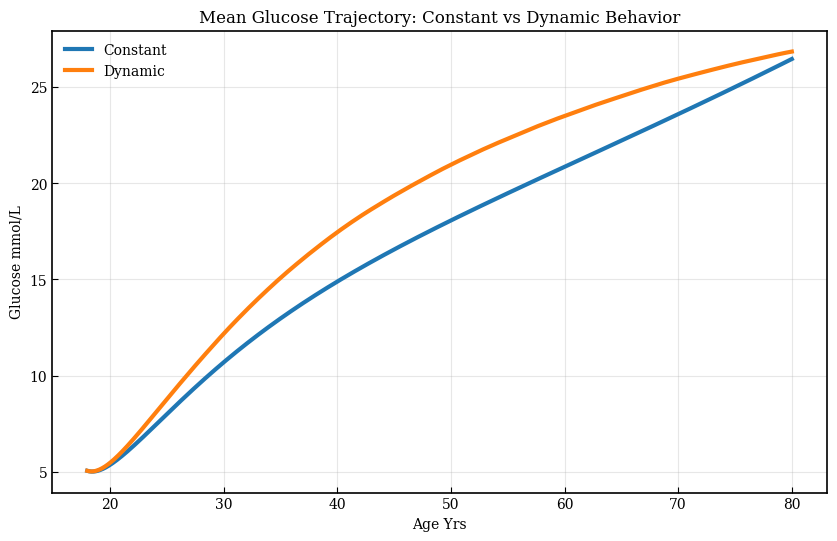

In [168]:
G_const = results[("empirical", "constant")][:, :, 0]
G_dyn   = results[("empirical", "dynamic")][:, :, 0]

mean_const = G_const.mean(axis=0)
mean_dyn   = G_dyn.mean(axis=0)

plt.figure(figsize=(10,6))

plt.plot(t_span, mean_const, label="Constant", linewidth=3)
plt.plot(t_span, mean_dyn, label="Dynamic", linewidth=3)

plt.xlabel("Age Yrs")
plt.ylabel("Glucose mmol/L")
plt.title("Mean Glucose Trajectory: Constant vs Dynamic Behavior")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

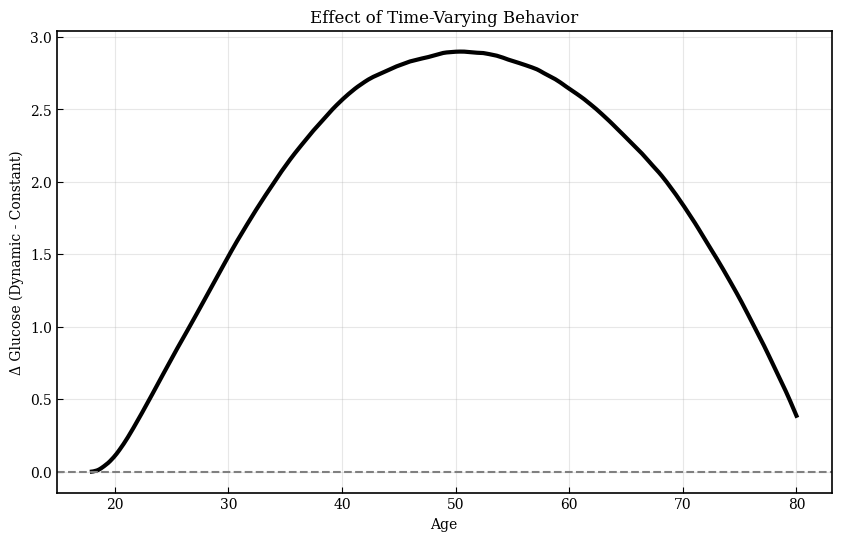

In [169]:
diff = mean_dyn - mean_const

plt.figure(figsize=(10,6))

plt.plot(t_span, diff, color='black', linewidth=3)
plt.axhline(0, linestyle='--', color='gray')

plt.xlabel("Age")
plt.ylabel("Δ Glucose (Dynamic - Constant)")
plt.title("Effect of Time-Varying Behavior")

plt.grid(alpha=0.3)
plt.show()

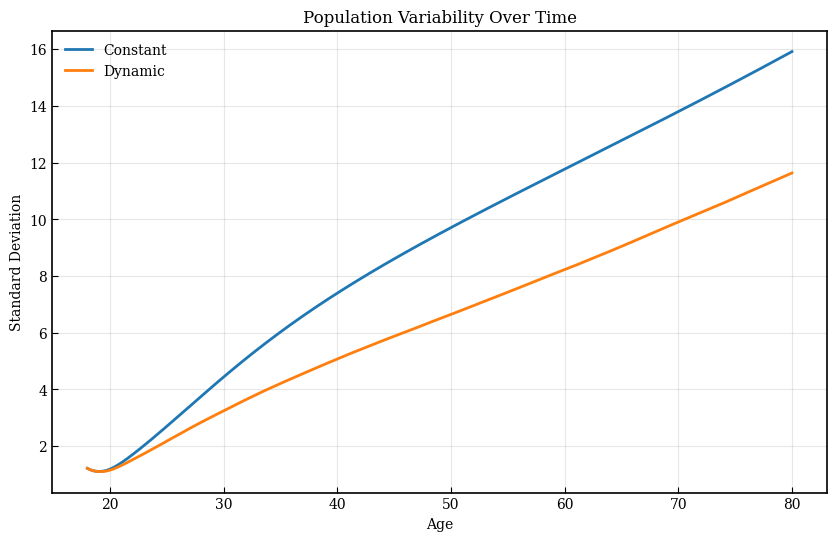

In [170]:
std_const = G_const.std(axis=0)
std_dyn   = G_dyn.std(axis=0)

plt.figure(figsize=(10,6))

plt.plot(t_span, std_const, label="Constant", linewidth=2)
plt.plot(t_span, std_dyn, label="Dynamic", linewidth=2)

plt.xlabel("Age")
plt.ylabel("Standard Deviation")
plt.title("Population Variability Over Time")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

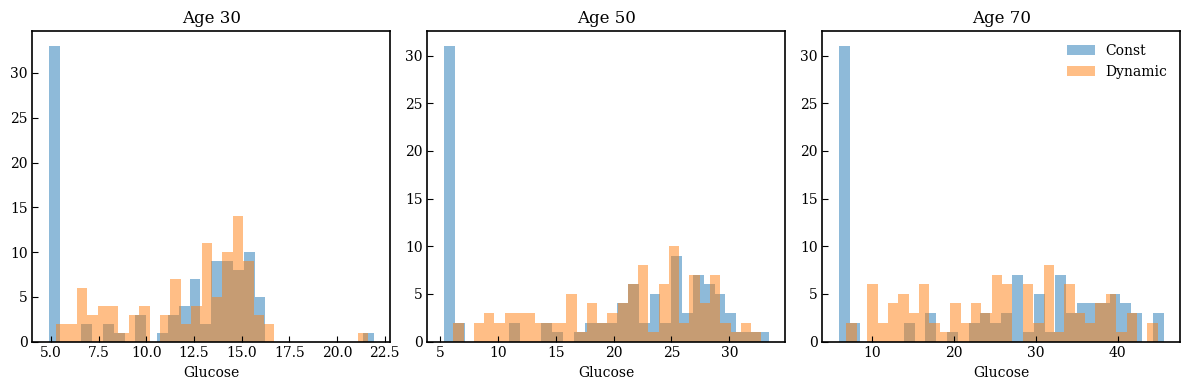

In [171]:
ages_to_check = [30, 50, 70]

plt.figure(figsize=(12,4))

for i, age in enumerate(ages_to_check):
    idx = int((age - 18) / (80 - 18) * (len(t_span)-1))

    plt.subplot(1,3,i+1)

    plt.hist(G_const[:, idx], bins=30, alpha=0.5, label="Const")
    plt.hist(G_dyn[:, idx], bins=30, alpha=0.5, label="Dynamic")

    plt.title(f"Age {age}")
    plt.xlabel("Glucose")

plt.legend()
plt.tight_layout()
plt.show()

##**Sampling, Simulation, and Likelihood-Based Training**

In [195]:
def reparameterized_sample(mus, sigmas, eps): # sample from log_normal distribution making sampling differentiable
    #scale = jax.nn.softplus(sigmas) + 1e-3
    scale = 0.1 * jax.nn.softplus(sigmas) + 0.01
    #scale = jax.nn.softplus(sigmas) +1e-3
    return jnp.exp(mus + scale * eps) #OPTION: jnp.exp(mus + 0*scale * eps)
    #return jnp.exp(mus + 0*scale * eps)

def calc_lppd(measurements, mask, sims, sigma):# Computes log predictive probability density
    diffs = sims - measurements[:, None]
    # Clamp differences
    #diffs = jnp.clip(diffs, -20.0, 20.0)
    #sigma = 0.5
    log_coef = -jnp.log(jnp.sqrt(2 * jnp.pi) * sigma)
    log_probs = (log_coef - 0.5 * (diffs / sigma)**2)
    lppd=jnp.nanmean(jax.nn.logmeanexp(log_probs, axis=1, where=mask[:, None]))
    #return jax.nn.logmeanexp(log_probs, axis=1, where=mask[:, None])
    return lppd


# Time safe indexing
def time_to_index(t, dt):
    return ((t - 18.0) / dt).astype(int)


def scan_loss_fn(optax_params, glucose, insulin, mask,mvpa_data, calorie_data, eps_fixed,eps2_fixed,keys_fixed): #main loss function; training objective
    mus = optax_params["mus"] # extract parameters; learned parameters optimized by optax
    sigmas = optax_params["sigmas"] #extract parameters

    dt=0.01
    t_span = jnp.linspace(18, 80, int((80-18)/dt+1))

    # Multivariate reparameterized sampling
    N = eps2_fixed.shape[0]


    L = jnp.linalg.cholesky(cov_jax)

    eps_gi = eps2_fixed

    gi_samples = mean_jax + eps_gi @ L.T

    G0 = gi_samples[:, 0]
    I0 = jnp.exp(gi_samples[:, 1])
    A0_samples = vectorized_samples[:G0.shape[0], -3]

    N = G0.shape[0]

    init_samples = jnp.column_stack([
        G0,
        jnp.full(N, params_cases["Red"]['B_0']),
        I0 ,
        jnp.full(N, params_cases["Red"]['S_0']),
        jnp.full(N, params_cases["Red"]['L_0']),
        A0_samples
    ])

    # parameter samples
    param_samples = jax.vmap(reparameterized_sample, in_axes=(None, None, 0))(mus, sigmas, eps_fixed)


    # Scan with inputs
    def simulate_one(param_ind, init_ind, mvpa, calories, key_i):

        F_traj, Y_traj = generate_behavior_trajectories(
            t_span,
            mvpa,
            calories,
            "constant",   # or dynamic
            key_i
        )

        base_params = dict(params_cases["Red"])
        for i, name in enumerate(theta_keys):
            base_params[name] = param_ind[i]

        def step(y, inputs):
            t, F_t, Y_t = inputs
            params_step = {**base_params, "F": F_t, "Y": Y_t}
            y_next, _ = ode_rhs_scan(y, t, param_ind, params_step, dt, init_ind)
            return y_next, y_next

        _, ys = jax.lax.scan(step, init_ind, (t_span, F_traj, Y_traj))

        return ys

    keys = keys_fixed
    states = jax.vmap(simulate_one)(param_samples, init_samples, mvpa_data, calorie_data, keys)

    # Midpoints
    ages = jnp.array(age_list)

    # convert age → index
    midpoints = ((ages - 18) / (80 - 18) * (states.shape[1] - 1)).astype(int)
    midpoints = jnp.clip(midpoints, 0, states.shape[1] - 1)

    # likelihood
    # ---- glucose likelihood ----
    logexps_glucose = jax.vmap(
        lambda glucose_bin, mask_bin, midpoint:
            calc_lppd(glucose_bin, mask_bin, jnp.log(states[:, midpoint, 0][None, :]+1e-6), sigma=0.1),
        (0, 0, 0)
    )(jnp.log(glucose+1e-6), mask, midpoints)

    # ---- insulin likelihood ----
    logexps_insulin = jax.vmap(
        lambda insulin_bin, mask_bin, midpoint:
            calc_lppd(insulin_bin,mask_bin,jnp.log(states[:, midpoint, 2][None, :] + 1e-6),sigma=0.1),
        (0, 0, 0)
    )(jnp.log(insulin + 1e-6), mask, midpoints)



     # separate means
    mean_glucose = jnp.nanmean(logexps_glucose)
    mean_insulin = jnp.nanmean(logexps_insulin)

    loss = -(mean_glucose/2.0 + mean_insulin/5.0)


    # return loss + aux
    return loss, (logexps_glucose, logexps_insulin, mean_glucose, mean_insulin)

def debug_simulation(optax_params, mvpa_data, calorie_data, eps_fixed,eps2_fixed,keys_fixed):

    mus = optax_params["mus"]
    sigmas = optax_params["sigmas"]

    dt = 0.01
    t_span = jnp.linspace(18, 80, int((80-18)/dt+1))

    # Multivariate reparameterized sampling
    N = eps2_fixed.shape[0]

    L = jnp.linalg.cholesky(cov_jax)

    eps_gi = eps2_fixed

    gi_samples = mean_jax + eps_gi @ L.T

    G0 = gi_samples[:, 0]
    I0 = jnp.exp(gi_samples[:, 1])
    A0_samples = vectorized_samples[:G0.shape[0], -3]

    N = G0.shape[0]

    init_samples = jnp.column_stack([
        G0,
        jnp.full(N, params_cases["Red"]['B_0']),
        I0,
        jnp.full(N, params_cases["Red"]['S_0']),
        jnp.full(N, params_cases["Red"]['L_0']),
        A0_samples
    ])

    param_samples = jax.vmap(reparameterized_sample, in_axes=(None, None, 0))(mus, sigmas, eps_fixed)
    #param_samples = jnp.clip(param_samples, 1e-6, None)

    def simulate_one(param_ind, init_ind, mvpa, calories, key_i):

        F_traj, Y_traj = generate_behavior_trajectories(
            t_span,
            mvpa,
            calories,
            "constant",   # or dynamic
            key_i
        )

        base_params = dict(params_cases["Red"])
        for i, name in enumerate(theta_keys):
            base_params[name] = param_ind[i]

        def step(y, inputs):
            t, F_t, Y_t = inputs
            params_step = {**base_params, "F": F_t, "Y": Y_t}
            y_next, _ = ode_rhs_scan(y, t, param_ind, params_step, dt, init_ind)
            return y_next, y_next

        _, ys = jax.lax.scan(step, init_ind, (t_span, F_traj, Y_traj))

        return ys
    # generate keys just like training
    keys = keys_fixed
    states = jax.vmap(simulate_one)(param_samples, init_samples, mvpa_data, calorie_data,keys)

    return t_span, states

## **Data Binning, Parameter Initialization and Training Loop**

In [196]:
# Set age-list
age_list = list(age_midpoints)

# Build bins
real_bins = {}
insulin_bins = {}

for age in age_list:
    subset = data_filtered[data_filtered["age_bin"] == age]
    subset_clean = subset[["glucose", "insulin"]].dropna()

    g_vals = subset_clean["glucose"].values
    i_vals = subset_clean["insulin"].values

    if len(g_vals) == 0:
        print(f"⚠️ Empty glucose bin at age {age}")

    if len(i_vals) == 0:
        print(f"⚠️ Empty insulin bin at age {age}")

    real_bins[age] = g_vals
    insulin_bins[age] = i_vals

age_list = [age for age in age_list if len(real_bins[age]) > 0]


# Get max_K
max_K = max(len(real_bins[age]) for age in age_list)


# Build arrays and masks
real_array = []
insulin_array = []
mask_array = []

for age in age_list:

    g_vals = real_bins[age]
    i_vals = insulin_bins[age]

    K = len(g_vals)

    # Pad both with same length
    g_padded = np.pad(g_vals, (0, max_K - K), constant_values=0.0)
    i_padded = np.pad(i_vals, (0, max_K - K), constant_values=0.0)

    # Single shared mask
    mask = np.concatenate([np.ones(K), np.zeros(max_K - K)])

    real_array.append(g_padded)
    insulin_array.append(i_padded)
    mask_array.append(mask)


# convert to JAX
real_array = jnp.array(real_array)
insulin_array = jnp.array(insulin_array)
mask_array = jnp.array(mask_array, dtype=bool)


# sanity check
print("real_array shape:", real_array.shape)
print("insulin_array shape:", insulin_array.shape)

for age in age_list:
    print(f"Age {age}: K = {len(real_bins[age])}")


mus = jnp.log(jnp.array([param_dist[k]["mu"] for k in theta_keys]))
#sigmas = jnp.log(jnp.array([param_dist[k]["sigma"] for k in theta_keys]))
sigmas = jnp.array([param_dist[k]["sigma"] for k in theta_keys])

#print(age_list)

#print(real_array[0])

# --- FIXED RANDOMNESS (DO THIS ONCE) ---
key, subkey1, subkey2, subkey3 = jax.random.split(key, 4)

eps_fixed  = jax.random.normal(subkey1, shape=(N_samples, 7))
eps2_fixed = jax.random.normal(subkey2, shape=(N_samples, 2))

# keys for behavior / simulation randomness
keys_fixed = jax.random.split(subkey3, N_samples)

optax_params = {"mus":mus,"sigmas":sigmas}

mvpa_data = jnp.clip(vectorized_samples[:, -2], 0.0, 1e4)
calorie_data = jnp.clip(vectorized_samples[:, -1], 0.0, 5000.0)

scan_loss_fn(optax_params,real_array,insulin_array, mask_array,mvpa_data,calorie_data,eps_fixed,eps2_fixed,keys_fixed)

optimizer = optax.adam(1e-1)
opt_state = optimizer.init(optax_params)

@jax.jit
def train_step(params, opt_state, real_array, insulin_array,mask_array,mvpa_data, calorie_data, eps_fixed, eps2_fixed, keys_fixed):
    N_samples = 100  # keep small initially

    (loss, aux), grads = jax.value_and_grad(scan_loss_fn, argnums=0, has_aux=True)(params,real_array,insulin_array,mask_array,mvpa_data,calorie_data,eps_fixed,eps2_fixed,keys_fixed)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss,aux

loss_history = []
glucose_history = []
insulin_history = []

resample_every = 1

pbar = tqdm(range(200))

for step in pbar:

    # 🔁 RESAMPLE STOCHASTICITY PERIODICALLY
    if step % resample_every == 0:
        key, k1, k2, k3 = jax.random.split(key, 4)

        eps_fixed  = jax.random.normal(k1, shape=(N_samples, 7))
        eps2_fixed = jax.random.normal(k2, shape=(N_samples, 2))
        keys_fixed = jax.random.split(k3, N_samples)

    # 🔧 TRAIN STEP (UNCHANGED)
    optax_params, opt_state, loss, aux = train_step(
        optax_params,
        opt_state,
        real_array,
        insulin_array,
        mask_array,
        mvpa_data,
        calorie_data,
        eps_fixed,
        eps2_fixed,
        keys_fixed
    )

    # ---- unpack aux ----
    log_g, log_i, mean_g, mean_i = aux

    loss_value = float(loss)
    mean_g_value = float(mean_g)
    mean_i_value = float(mean_i)

    loss_history.append(loss_value)
    glucose_history.append(mean_g_value)
    insulin_history.append(mean_i_value)

    pbar.set_postfix({
        "loss": loss_value,
        "glucose": mean_g_value,
        "insulin": mean_i_value
    })
print(loss)
print(optax_params)

real_array shape: (7, 308)
insulin_array shape: (7, 308)
Age 15: K = 31
Age 25: K = 302
Age 35: K = 308
Age 45: K = 275
Age 55: K = 249
Age 65: K = 307
Age 75: K = 207


100%|██████████| 200/200 [00:33<00:00,  6.05it/s, loss=0.348, glucose=0.108, insulin=-2.01]

0.34805465
{'mus': Array([ -6.4921865,  -5.3031573,  -1.703597 ,  -4.4643807,  -9.606963 ,
       -13.185594 ,  -9.979631 ], dtype=float32), 'sigmas': Array([ 0.46748865,  9.84863   ,  8.720966  , -1.4230721 ,  0.40001598,
        7.361048  ,  1.1209401 ], dtype=float32)}


##**Loss convergence plot**

Saved: lppd_convergence_combined_20260514_221831.png


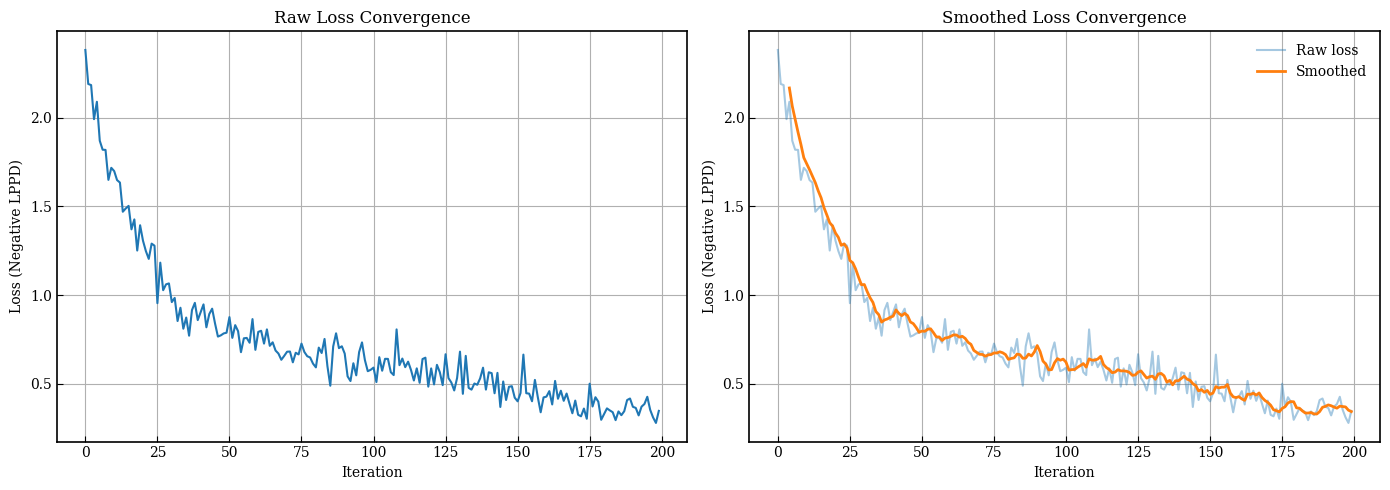

In [197]:
window = 5
smoothed_loss = np.convolve(loss_history, np.ones(window)/window, mode='valid')

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- LEFT: Raw loss ---
axes[0].plot(loss_history)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Loss (Negative LPPD)")
axes[0].set_title("Raw Loss Convergence")
axes[0].grid()

# --- RIGHT: Smoothed + raw ---
axes[1].plot(loss_history, alpha=0.4, label="Raw loss")
axes[1].plot(range(window-1, len(loss_history)),
             smoothed_loss,
             linewidth=2,
             label="Smoothed")

axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Loss (Negative LPPD)")
axes[1].set_title("Smoothed Loss Convergence")
axes[1].legend()
axes[1].grid()

# Layout
plt.tight_layout()

# Save combined figure
save_figure(fig, "lppd_convergence_combined")

plt.show()

In [198]:
def softplus(x):
    return jnp.log(1 + jnp.exp(x))

mu_vals = optax_params["mus"]
sigma_raw = optax_params["sigmas"]
sigma_eff = softplus(sigma_raw)

print("mu:", mu_vals)
print("sigma_eff:", sigma_eff)

mu: [ -6.4921865  -5.3031573  -1.703597   -4.4643807  -9.606963  -13.185594
  -9.979631 ]
sigma_eff: [0.95396453 9.848682   8.721129   0.21589546 0.9130248  7.3616834
 1.4030868 ]


In [199]:
print(optax_params)
#optax_params["mus"] = 0.001*jnp.ones_like(optax_params["mus"])
for i in range(7,):
    print(np.mean(real_array[i][mask_array[i]]))
key, subkey = jax.random.split(key)
eps = jax.random.normal(subkey, shape=(N_samples, 7))
eps2_fixed = jax.random.normal(subkey, shape=(N_samples, 2))
scan_loss_fn(optax_params,real_array,insulin_array, mask_array,mvpa_data,calorie_data,eps_fixed,eps2_fixed,keys_fixed)

{'mus': Array([ -6.4921865,  -5.3031573,  -1.703597 ,  -4.4643807,  -9.606963 ,
       -13.185594 ,  -9.979631 ], dtype=float32), 'sigmas': Array([ 0.46748865,  9.84863   ,  8.720966  , -1.4230721 ,  0.40001598,
        7.361048  ,  1.1209401 ], dtype=float32)}
4.9855485
5.022298
5.300318
5.709782
6.3046703
6.545052
6.2653713


(Array(0.32279432, dtype=float32),
 (Array([ 0.46364895,  0.38807398,  0.13993303,  0.09013516, -0.15359588,
         -0.17949156, -0.15617737], dtype=float32),
  Array([-2.756637 , -2.0864103, -2.081175 , -1.4749044, -1.6510789,
         -1.4330746, -1.2958373], dtype=float32),
  Array(0.08464662, dtype=float32),
  Array(-1.8255882, dtype=float32)))

## **Visualization of Model Trajectories and Data Comparison Across Age Bins**

In [200]:
def plot_glucose_insulin(states, t_span, age_list, real_bins, insulin_bins):

    states_np = np.array(states)
    t_span_np = np.array(t_span)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))


    # GLUCOSE

    ax = axes[0]

    # --- trajectories ---
    for i in range(states_np.shape[0]):
        ax.plot(t_span_np, states_np[i,:,0], alpha=0.15, color='gray')

    # --- mean + confidence band ---
    mean_G = states_np[:,:,0].mean(axis=0)
    std_G = states_np[:,:,0].std(axis=0)

    ax.plot(t_span_np, mean_G, color='black', linewidth=2, label='Model mean')
    ax.fill_between(t_span_np, mean_G - std_G, mean_G + std_G,
                    color='blue', alpha=0.2, label='Model ±1 std')

    # --- real data ---
    for age in age_list:
        vals = real_bins[age]
        ax.scatter([age]*len(vals), vals,
                   color='red', alpha=0.15, s=10, label='Data' if age == age_list[0] else "")

    # --- model samples at same ages ---
    for age in age_list:
        idx = np.argmin(np.abs(t_span_np - age))
        model_vals = states_np[:, idx, 0]

        ax.scatter([age]*len(model_vals), model_vals,
                   color='blue', alpha=0.2, s=10,
                   label='Model samples' if age == age_list[0] else "")

    ax.set_title("Glucose: Model vs Data")
    ax.set_xlabel("Age")
    ax.set_ylabel("Glucose")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # INSULIN (LOG SPACE)

    ax = axes[1]

    model_I = np.log(states_np[:,:,2] + 1e-6)

    # --- trajectories ---
    for i in range(model_I.shape[0]):
        ax.plot(t_span_np, model_I[i], alpha=0.15, color='gray')

    # --- mean + confidence ---
    mean_I = model_I.mean(axis=0)
    std_I = model_I.std(axis=0)

    ax.plot(t_span_np, mean_I, color='black', linewidth=2, label='Model mean')
    ax.fill_between(t_span_np, mean_I - std_I, mean_I + std_I,
                    color='blue', alpha=0.2, label='Model ±1 std')

    # --- real data ---
    for age in age_list:
        vals = insulin_bins[age]
        data_I = np.log(vals + 1e-6)

        ax.scatter([age]*len(data_I), data_I,
                   color='red', alpha=0.25, s=10,
                   label='Data' if age == age_list[0] else "")

    # --- model samples at same ages ---
    for age in age_list:
        idx = np.argmin(np.abs(t_span_np - age))
        model_vals = np.log(states_np[:, idx, 2] + 1e-6)

        ax.scatter([age]*len(model_vals), model_vals,
                   color='blue', alpha=0.25, s=10,
                   label='Model samples' if age == age_list[0] else "")

    ax.set_title("Insulin (log): Model vs Data")
    ax.set_xlabel("Age")
    ax.set_ylabel("log(Insulin)")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # =========================
    plt.suptitle("Model Behavior vs Real Data", fontsize=16)
    plt.tight_layout()
    save_figure(fig, "Model Behavior vs Real Data")
    plt.show()


def plot_all_states(states, t_span):

    states_np = np.array(states)
    t_span_np = np.array(t_span)

    state_info = [
        {
            "title": r"Glucose $G(t)$",
            "ylabel": r"$G(t)$ [mmol/L]"
        },
        {
            "title": r"Beta cells $B(t)$",
            "ylabel": r"$B(t)$ [$10^9$ cells]"
        },
        {
            "title": r"Insulin $I(t)$",
            "ylabel": r"$I(t)$ [pmol/L]"
        },
        {
            "title": r"Sensitivity $S(t)$",
            "ylabel": r"$S(t)$ [L/yr/pM]"
        },
        {
            "title": r"Liver $L(t)$",
            "ylabel": r"$L(t)$ [mM/pM]"
        }
    ]

    #labels = ["Glucose (G)", "Beta cells (B)", "Insulin (I)", "Sensitivity (S)", "Liver (L)"]

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()

    for i in range(5):
        ax = axes[i]

        # trajectories
        for j in range(states_np.shape[0]):
            ax.plot(t_span_np, states_np[j,:,i], alpha=0.2)

        # mean
        mean_traj = states_np[:,:,i].mean(axis=0)
        ax.plot(t_span_np, mean_traj, linewidth=2)

        ax.set_title(state_info[i]["title"], fontsize=13)
        ax.set_xlabel("Age Yrs")
        ax.set_ylabel(state_info[i]["ylabel"])
        ax.grid(True, alpha=0.3)

    fig.delaxes(axes[5])

    plt.suptitle("Simulated Physiological Trajectories", fontsize=16)
    plt.tight_layout()
    save_figure(fig, "Simulated Physiological Trajectories")
    plt.show()

Saved: Model Behavior vs Real Data_20260514_221920.png


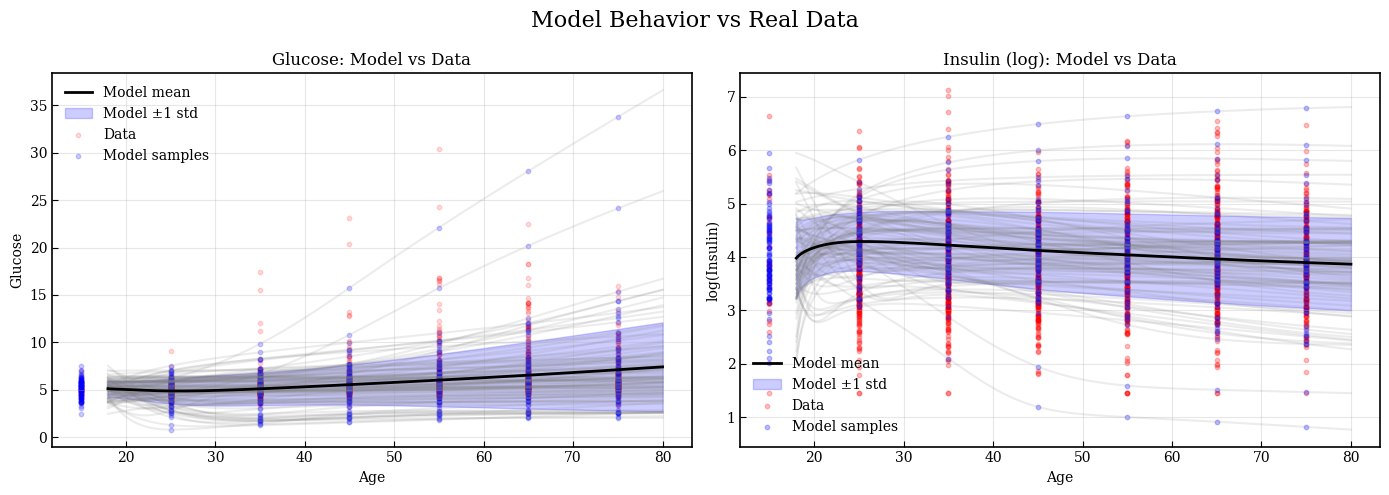

Saved: Simulated Physiological Trajectories_20260514_221927.png


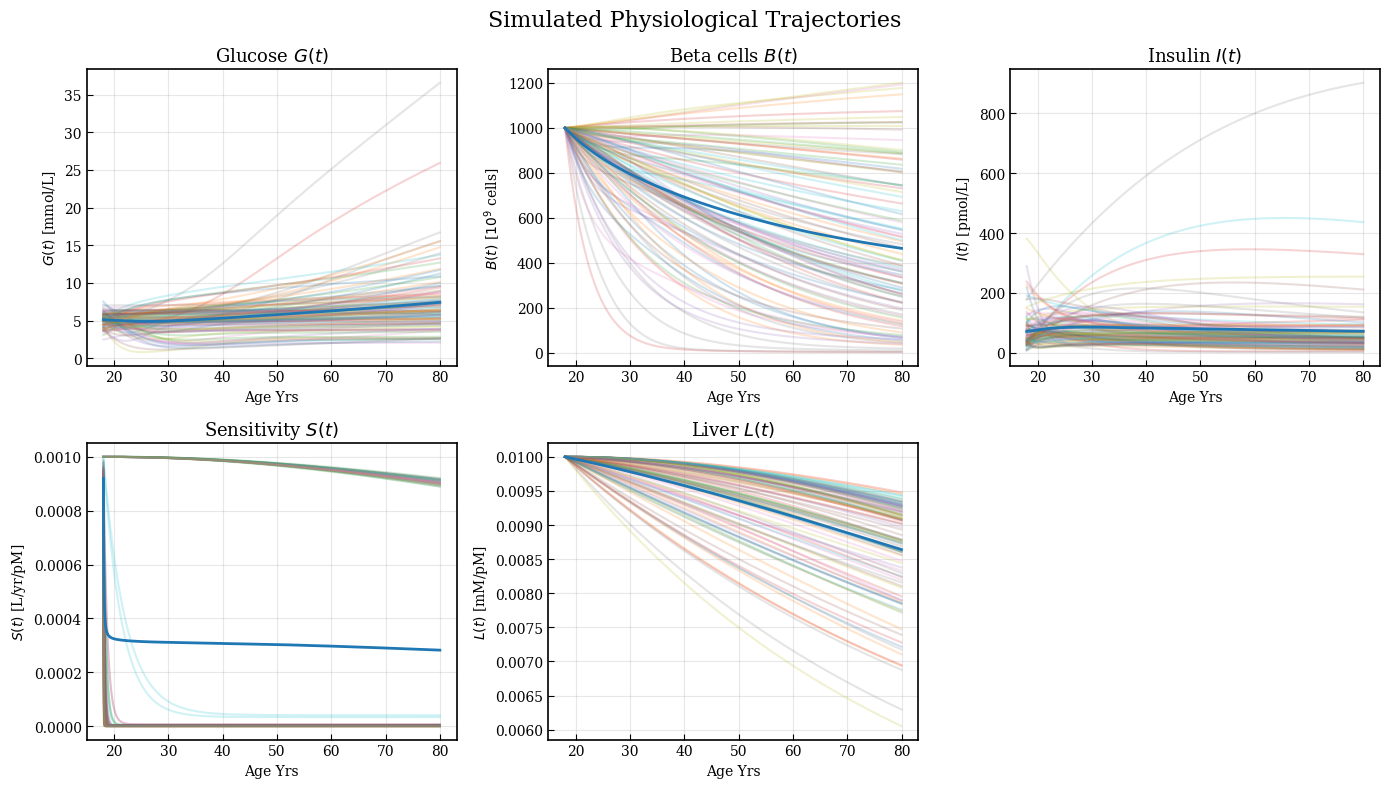

In [201]:
# --- regenerate noise
key, subkey1, subkey2 = jax.random.split(key, 3)

eps  = jax.random.normal(subkey1, shape=(N_samples, 7))
eps2 = jax.random.normal(subkey2, shape=(N_samples, 2))

# --- simulate ---
t_span, states = debug_simulation(optax_params, mvpa_data, calorie_data, eps, eps2,keys_fixed)

# --- plot ---
plot_glucose_insulin(states, t_span, age_list, real_bins, insulin_bins)
plot_all_states(states, t_span)

In [179]:
print("Raw glucose stats:")
print("Min:", data_filtered["glucose"].min())
print("Max:", data_filtered["glucose"].max())

print("\nQuantiles:")
print(data_filtered["glucose"].quantile([0, 0.01, 0.05, 0.5, 0.95, 0.99, 1.0]))

high_vals = data_filtered[data_filtered["glucose"] > 15]

print("Number of glucose > 15:", len(high_vals))
print("Percentage:", len(high_vals) / len(data_filtered) * 100)

print(high_vals[["age", "glucose"]].head(20))

Raw glucose stats:
Min: 2.537
Max: 30.397

Quantiles:
0.00     2.53700
0.01     3.76174
0.05     4.39100
0.50     5.33500
0.95     9.00410
0.99    15.46874
1.00    30.39700
Name: glucose, dtype: float64
Number of glucose > 15: 18
Percentage: 1.0720667063728408
       age  glucose
266   45.0   23.092
632   43.0   20.417
999   61.0   18.235
1599  61.0   16.792
1616  37.0   15.521
2240  55.0   16.831
4242  51.0   30.397
4883  55.0   24.297
6009  63.0   22.532
7078  58.0   16.187
7635  74.0   15.909
7697  36.0   17.458
8170  52.0   16.597
8773  52.0   16.775
8940  64.0   16.098
9160  51.0   16.475
9281  76.0   15.454
9327  68.0   18.274


Saved: distribution_comparison_age_45_20260514_215141.png


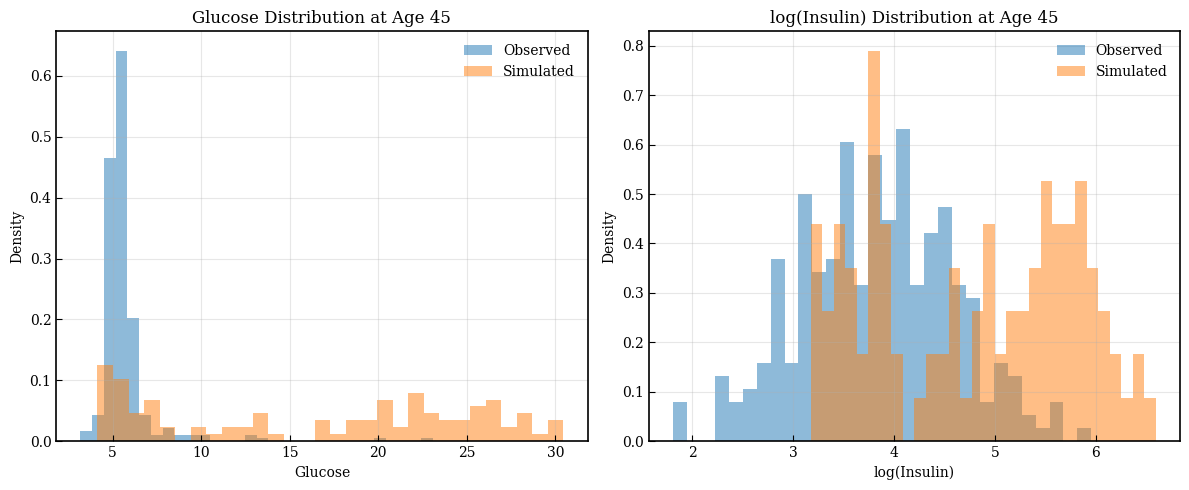

In [180]:
def plot_distribution_comparison(states, t_span, age_list, real_bins, insulin_bins, age_target):

    states_np = np.array(states)
    t_span_np = np.array(t_span)

    # find closest index to chosen age
    idx = np.argmin(np.abs(t_span_np - age_target))

    # get data
    real_g = real_bins[age_target]
    sim_g  = states_np[:, idx, 0]

    real_i = np.log(insulin_bins[age_target] + 1e-6)
    sim_i  = np.log(states_np[:, idx, 2] + 1e-6)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- GLUCOSE ---
    axes[0].hist(real_g, bins=30, alpha=0.5, density=True, label="Observed")
    axes[0].hist(sim_g,  bins=30, alpha=0.5, density=True, label="Simulated")

    axes[0].set_title(f"Glucose Distribution at Age {age_target}")
    axes[0].set_xlabel("Glucose")
    axes[0].set_ylabel("Density")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # --- INSULIN (LOG) ---
    axes[1].hist(real_i, bins=30, alpha=0.5, density=True, label="Observed")
    axes[1].hist(sim_i,  bins=30, alpha=0.5, density=True, label="Simulated")

    axes[1].set_title(f"log(Insulin) Distribution at Age {age_target}")
    axes[1].set_xlabel("log(Insulin)")
    axes[1].set_ylabel("Density")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    save_figure(fig, f"distribution_comparison_age_{age_target}")
    plt.show()

plot_distribution_comparison(
    states,
    t_span,
    age_list,
    real_bins,
    insulin_bins,
    age_target=45   #
)

In [181]:
print("t_span shape:", t_span.shape)
print("G_const[i] shape:", G_const[i].shape)

t_span shape: (6201,)
G_const[i] shape: (1000,)


Saved: Behavioral impact experiments_20260514_215142.png


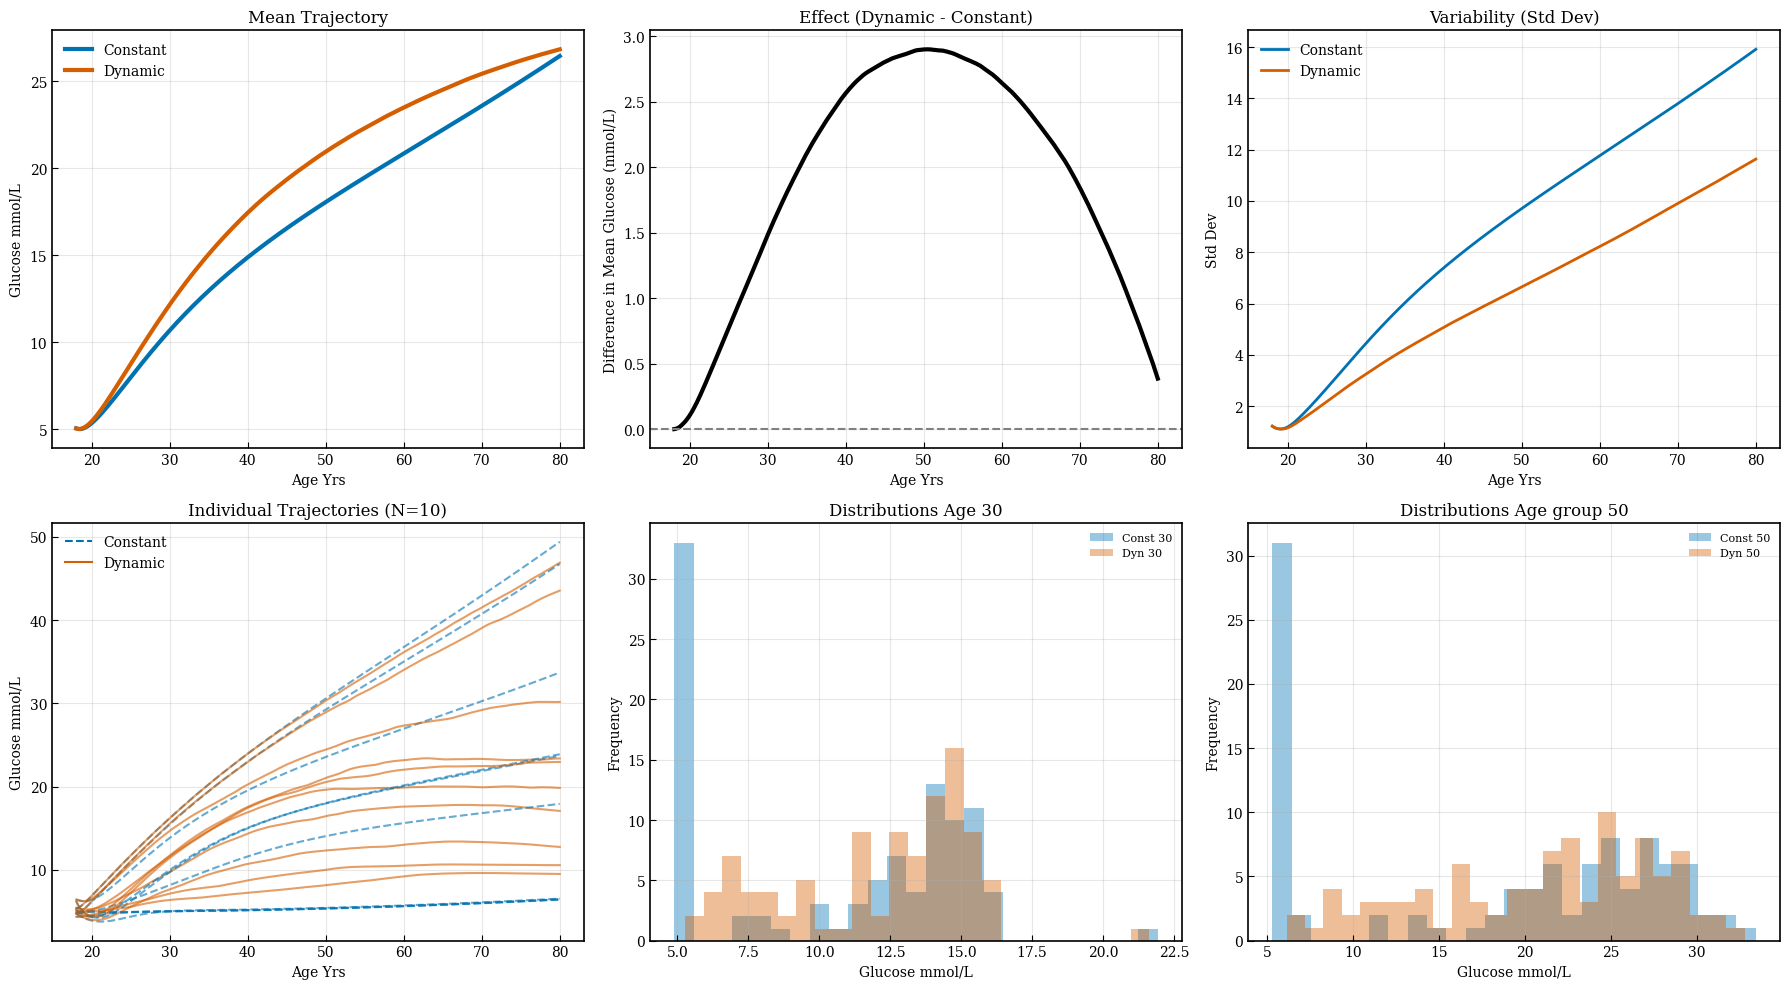

In [182]:
# =============================================================================
# COMBINED FIGURE
# =============================================================================
t_span = jnp.linspace(18, 80, 1000)
# Extract data
G_const = results[("empirical", "constant")][:, :, 0]
G_dyn   = results[("empirical", "dynamic")][:, :, 0]

# Statistics
mean_const = G_const.mean(axis=0)
mean_dyn   = G_dyn.mean(axis=0)

std_const = G_const.std(axis=0)
std_dyn   = G_dyn.std(axis=0)

diff = mean_dyn - mean_const

# Ages for histogram snapshots
ages_to_check1 = [30] #[30, 50]
indices1 = [
    int((age - 18) / (80 - 18) * (len(t_span)-1))
    for age in ages_to_check1
]

ages_to_check2 = [50] #[30, 50]
indices2 = [
    int((age - 18) / (80 - 18) * (len(t_span)-1))
    for age in ages_to_check2
]

# Select 10 individuals (fixed for consistency)
np.random.seed(0)
indices_individuals = np.random.choice(G_const.shape[0], size=10, replace=False)

# =============================================================================
# CREATE FIGURE
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Define consistent colors
CONST_COLOR = "#0072B2"
DYN_COLOR   = "#D55E00"

# -------------------------------
# (1) Mean trajectories
# -------------------------------
ax = axes[0, 0]
ax.plot(t_span, mean_const, label="Constant", linewidth=3,color=CONST_COLOR)
ax.plot(t_span, mean_dyn, label="Dynamic", linewidth=3,color=DYN_COLOR)
ax.set_title("Mean Trajectory")
ax.set_xlabel("Age Yrs")
ax.set_ylabel("Glucose mmol/L")
ax.legend()
ax.grid(alpha=0.3)

# -------------------------------
# (2) Difference curve
# -------------------------------
ax = axes[0, 1]
ax.plot(t_span, diff, color='black', linewidth=3)
ax.axhline(0, linestyle='--', color='gray')
ax.set_title("Effect (Dynamic - Constant)")
ax.set_xlabel("Age Yrs")
ax.set_ylabel("Difference in Mean Glucose (mmol/L)")
ax.grid(alpha=0.3)

# -------------------------------
# (3) Variability
# -------------------------------
ax = axes[0, 2]
ax.plot(t_span, std_const, label="Constant", linewidth=2, color=CONST_COLOR)
ax.plot(t_span, std_dyn, label="Dynamic", linewidth=2, color=DYN_COLOR)
ax.set_title("Variability (Std Dev)")
ax.set_xlabel("Age Yrs")
ax.set_ylabel("Std Dev")
ax.legend()
ax.grid(alpha=0.3)

# -------------------------------
# (4) Individual trajectories (N=10)
# -------------------------------
ax = axes[1, 0]

for idx in indices_individuals:
    ax.plot(t_span, G_const[idx], linestyle='--', alpha=0.6, color=CONST_COLOR)
    ax.plot(t_span, G_dyn[idx], linestyle='-', alpha=0.6, color=DYN_COLOR)

ax.set_title("Individual Trajectories (N=10)")
ax.set_xlabel("Age Yrs")
ax.set_ylabel("Glucose mmol/L")

# Legend proxy
ax.plot([], [], '--', color=CONST_COLOR, label='Constant')
ax.plot([], [], '-', color=DYN_COLOR, label='Dynamic')
ax.legend()

ax.grid(alpha=0.3)

# -------------------------------
# (5) Distribution snapshots
# -------------------------------
ax = axes[1, 1]

for idx, age in zip(indices1, ages_to_check1):
    ax.hist(
        G_const[:, idx],
        bins=25,
        alpha=0.4,
        label=f"Const {age}",
        color=CONST_COLOR
    )

    ax.hist(
        G_dyn[:, idx],
        bins=25,
        alpha=0.4,
        label=f"Dyn {age}",
        color=DYN_COLOR
    )

ax.set_title("Distributions Age 30")
ax.set_xlabel("Glucose mmol/L")
ax.set_ylabel("Frequency")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# -------------------------------
# (6) Empty / optional panel
# -------------------------------
ax = axes[1, 2]
for idx, age in zip(indices2, ages_to_check2):
    ax.hist(G_const[:, idx], bins=25, alpha=0.4, label=f"Const {age}",color=CONST_COLOR)
    ax.hist(G_dyn[:, idx], bins=25, alpha=0.4, label=f"Dyn {age}", color=DYN_COLOR)

ax.set_title("Distributions Age group 50")
ax.set_xlabel("Glucose mmol/L")
ax.set_ylabel("Frequency")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# -------------------------------
# Layout
# -------------------------------
plt.tight_layout()
save_figure(fig, "Behavioral impact experiments")
plt.show()

Saved: initial_state_sensitivity_full_20260514_215145.png


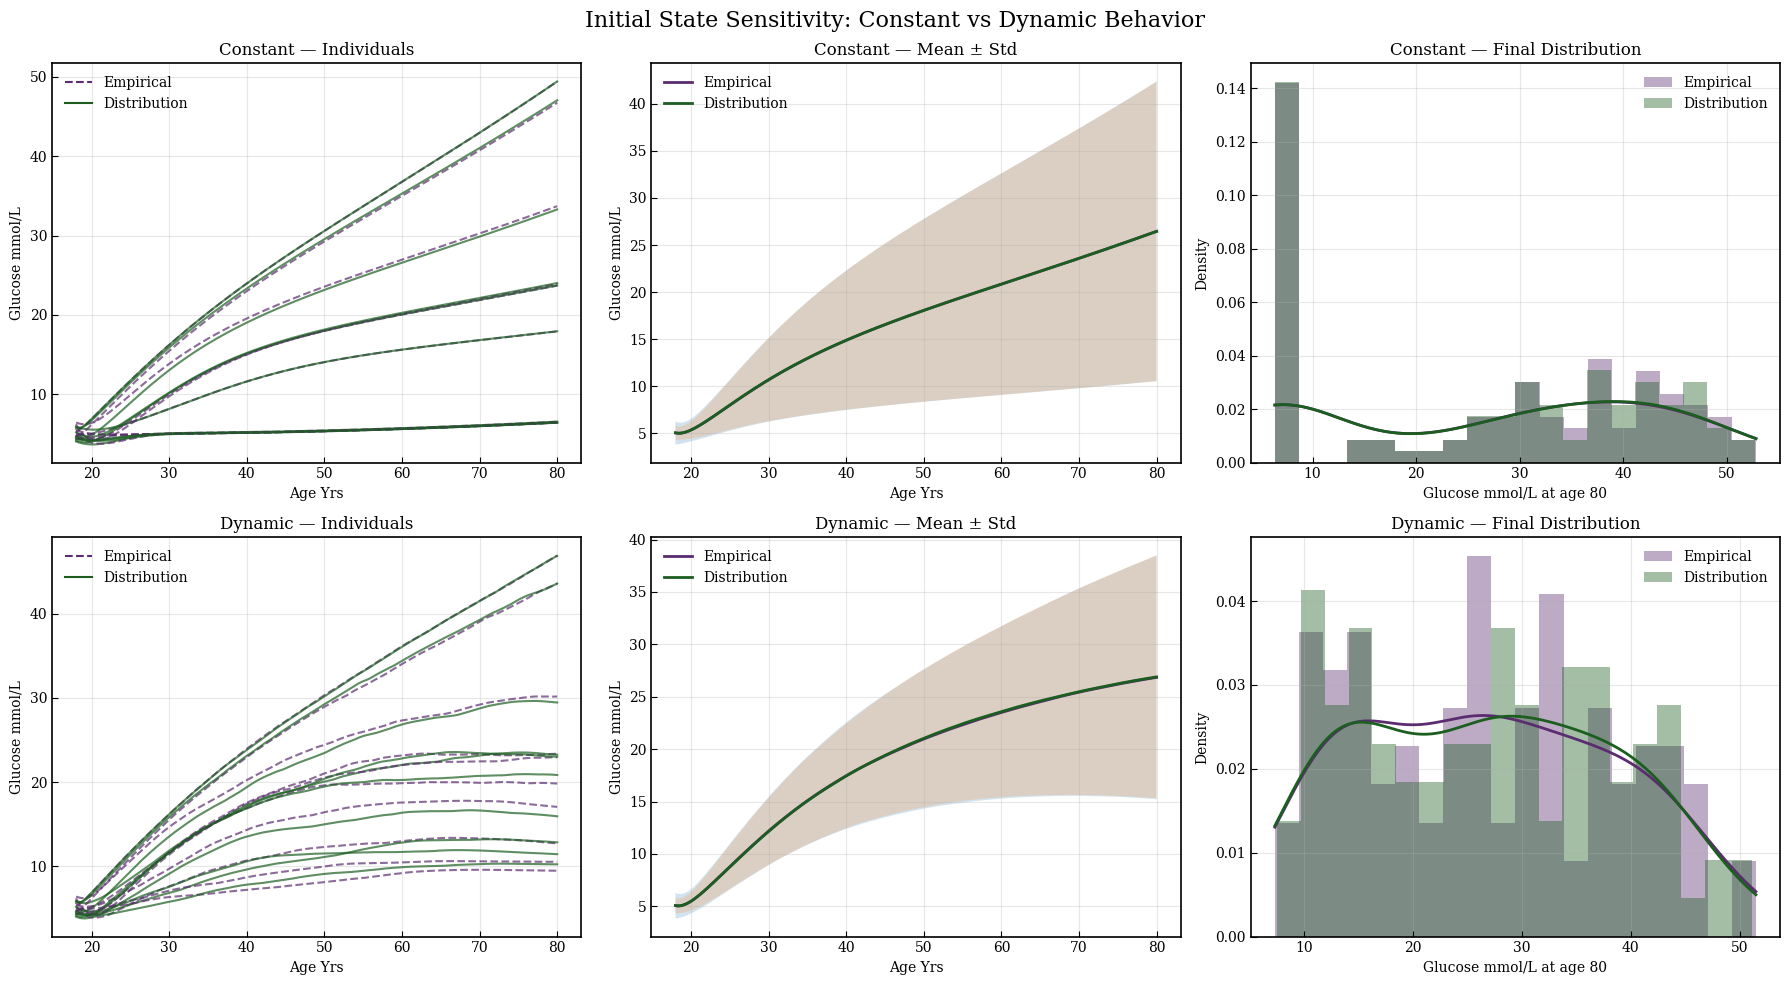

In [183]:
# =============================================================================
# INITIAL STATE SENSITIVITY — CONSTANT vs DYNAMIC (STACKED)
# =============================================================================

import scipy.stats as stats

EMP_COLOR  = "#5B2C6F"   # deep purple
DIST_COLOR = "#1B5E20"   # dark green

# --- Precompute final distributions ---
G_final_emp_const  = np.array(results[("empirical", "constant")][:, -1, 0])
G_final_dist_const = np.array(results[("distribution", "constant")][:, -1, 0])

G_final_emp_dyn  = np.array(results[("empirical", "dynamic")][:, -1, 0])
G_final_dist_dyn = np.array(results[("distribution", "dynamic")][:, -1, 0])

# --- Create figure: 2 rows × 3 columns ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Define consistent colors

modes = ["constant", "dynamic"]

for row, behavior_mode in enumerate(modes):

    # ================================
    # DATA
    # ================================
    G_emp  = results[("empirical", behavior_mode)][:, :, 0]
    G_dist = results[("distribution", behavior_mode)][:, :, 0]

    mean_G_emp  = G_emp.mean(axis=0)
    std_G_emp   = G_emp.std(axis=0)

    mean_G_dist = G_dist.mean(axis=0)
    std_G_dist  = G_dist.std(axis=0)

    # same individuals
    np.random.seed(0)
    idx_subset = np.random.choice(G_emp.shape[0], size=10, replace=False)

    # ================================
    # LEFT — Individual trajectories
    # ================================
    ax = axes[row, 0]

    for i in idx_subset:
        ax.plot(t_span, G_emp[i], '--', alpha=0.7,color=EMP_COLOR)
        ax.plot(t_span, G_dist[i], '-', alpha=0.7,color=DIST_COLOR)

    ax.set_title(f"{behavior_mode.capitalize()} — Individuals")
    ax.set_xlabel("Age Yrs")
    ax.set_ylabel("Glucose mmol/L")

    ax.plot([], [], '--',color=EMP_COLOR, label='Empirical')
    ax.plot([], [], '-',color=DIST_COLOR, label='Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # ================================
    # MIDDLE — Mean ± std
    # ================================
    ax = axes[row, 1]

    ax.plot(t_span, mean_G_emp, label="Empirical", linewidth=2,color=EMP_COLOR)
    ax.fill_between(t_span, mean_G_emp - std_G_emp, mean_G_emp + std_G_emp, alpha=0.2)

    ax.plot(t_span, mean_G_dist, label="Distribution", linewidth=2,color=DIST_COLOR)
    ax.fill_between(t_span, mean_G_dist - std_G_dist, mean_G_dist + std_G_dist, alpha=0.2)

    ax.set_title(f"{behavior_mode.capitalize()} — Mean ± Std")
    ax.set_xlabel("Age Yrs")
    ax.set_ylabel("Glucose mmol/L")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # ================================
    # RIGHT — Final distribution
    # ================================
    ax = axes[row, 2]

    if behavior_mode == "constant":
        G_emp_final = G_final_emp_const
        G_dist_final = G_final_dist_const
    else:
        G_emp_final = G_final_emp_dyn
        G_dist_final = G_final_dist_dyn

    # histogram
    ax.hist(G_emp_final, bins=20, density=True, alpha=0.4, label="Empirical",color=EMP_COLOR)
    ax.hist(G_dist_final, bins=20, density=True, alpha=0.4, label="Distribution",color=DIST_COLOR)

    # KDE
    x = np.linspace(min(G_emp_final.min(), G_dist_final.min()),
                    max(G_emp_final.max(), G_dist_final.max()), 200)

    kde_emp  = stats.gaussian_kde(G_emp_final)
    kde_dist = stats.gaussian_kde(G_dist_final)

    ax.plot(x, kde_emp(x), linewidth=2,color=EMP_COLOR)
    ax.plot(x, kde_dist(x), linewidth=2, color=DIST_COLOR)

    ax.set_title(f"{behavior_mode.capitalize()} — Final Distribution")
    ax.set_xlabel("Glucose mmol/L at age 80")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)

# ================================
# GLOBAL TITLE
# ================================
plt.suptitle("Initial State Sensitivity: Constant vs Dynamic Behavior", fontsize=16)

plt.tight_layout()
save_figure(fig, "initial_state_sensitivity_full")

plt.show()

constant → (100, 1000, 6)
dynamic → (100, 1000, 6)
Saved: Behavioral Input Sensitivity: Real vs Stochastic_20260514_215148.png


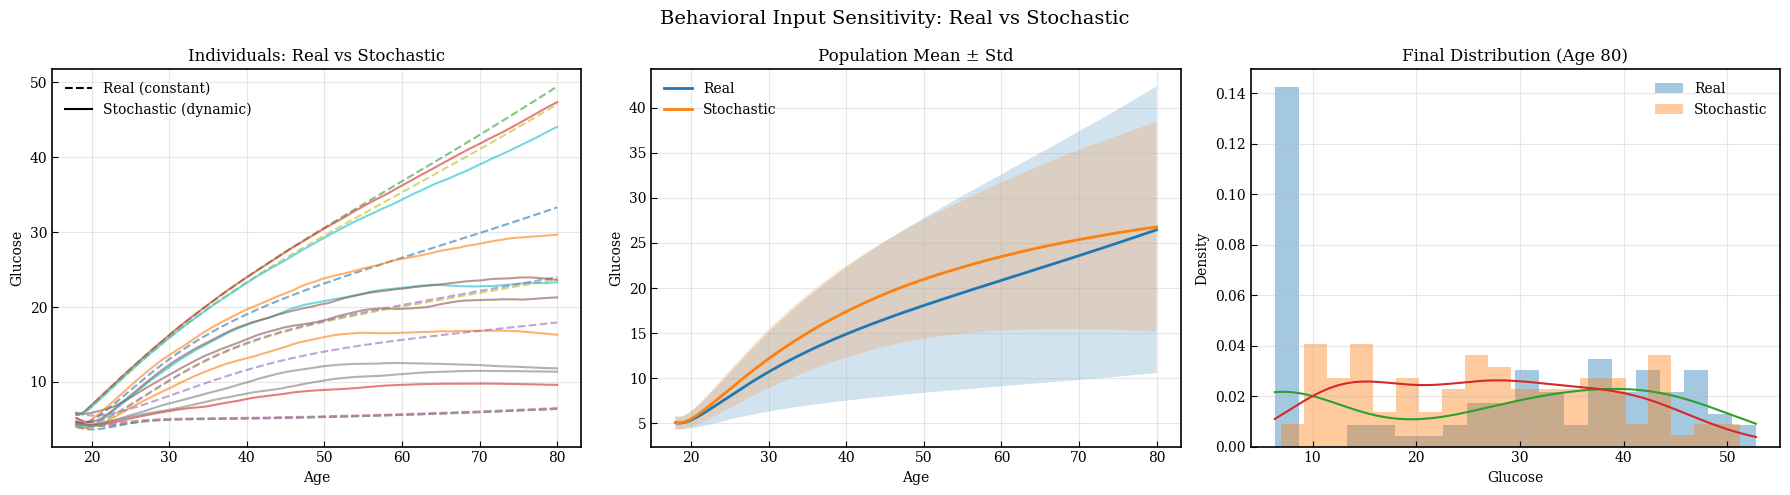

In [184]:
behavior_mode = "constant"
mvpa_real = vectorized_samples[:, -2]
cal_real  = vectorized_samples[:, -1]
behavior_mode = "dynamic"
mvpa_stochastic = vectorized_samples[:, -2]
cal_stochastic  = vectorized_samples[:, -1]

results_behavior = {}

for behavior_mode in ["constant", "dynamic"]:

    key, subkey = jax.random.split(key)

    states = simulate_population(
        init_states=init_distribution,   # or empirical — choose ONE
        mvpa0=mvpa_samples,
        cal0=calorie_samples,
        behavior_mode=behavior_mode,
        key=subkey
    )

    results_behavior[behavior_mode] = states

    print(f"{behavior_mode} → {states.shape}")

G_real = results_behavior["constant"][:, :, 0]
G_stoch = results_behavior["dynamic"][:, :, 0]

mean_real = G_real.mean(axis=0)
std_real  = G_real.std(axis=0)

mean_stoch = G_stoch.mean(axis=0)
std_stoch  = G_stoch.std(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -------------------------------
# 1. Individual trajectories
# -------------------------------
np.random.seed(0)
idx_subset = np.random.choice(G_real.shape[0], size=10, replace=False)

for i in idx_subset:
    axes[0].plot(t_span, G_real[i], '--', alpha=0.6)
    axes[0].plot(t_span, G_stoch[i], '-', alpha=0.6)

axes[0].set_title("Individuals: Real vs Stochastic")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Glucose")

axes[0].plot([], [], '--', color='black', label='Real (constant)')
axes[0].plot([], [], '-', color='black', label='Stochastic (dynamic)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# -------------------------------
# 2. Mean ± std
# -------------------------------
axes[1].plot(t_span, mean_real, label="Real", linewidth=2)
axes[1].fill_between(t_span, mean_real - std_real, mean_real + std_real, alpha=0.2)

axes[1].plot(t_span, mean_stoch, label="Stochastic", linewidth=2)
axes[1].fill_between(t_span, mean_stoch - std_stoch, mean_stoch + std_stoch, alpha=0.2)

axes[1].set_title("Population Mean ± Std")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Glucose")
axes[1].legend()
axes[1].grid(True, alpha=0.3)


# -------------------------------
# 3. Final distribution
# -------------------------------
G_final_real = np.array(G_real[:, -1])
G_final_stoch = np.array(G_stoch[:, -1])

axes[2].hist(G_final_real, bins=20, density=True, alpha=0.4, label="Real")
axes[2].hist(G_final_stoch, bins=20, density=True, alpha=0.4, label="Stochastic")

x = np.linspace(min(G_final_real.min(), G_final_stoch.min()),
                max(G_final_real.max(), G_final_stoch.max()), 200)

import scipy.stats as stats
axes[2].plot(x, stats.gaussian_kde(G_final_real)(x))
axes[2].plot(x, stats.gaussian_kde(G_final_stoch)(x))

axes[2].set_title("Final Distribution (Age 80)")
axes[2].set_xlabel("Glucose")
axes[2].set_ylabel("Density")
axes[2].legend()
axes[2].grid(True, alpha=0.3)


plt.suptitle("Behavioral Input Sensitivity: Real vs Stochastic", fontsize=14)
plt.tight_layout()
save_figure(fig,"Behavioral Input Sensitivity: Real vs Stochastic")
plt.show()

k_OI × 0.5 done
k_OI × 0.8 done
k_OI × 1.0 done
k_OI × 1.2 done
k_OI × 1.5 done
lambda_BA × 0.5 done
lambda_BA × 0.8 done
lambda_BA × 1.0 done
lambda_BA × 1.2 done
lambda_BA × 1.5 done
Saved: parameter sensitivity_20260514_215152.png


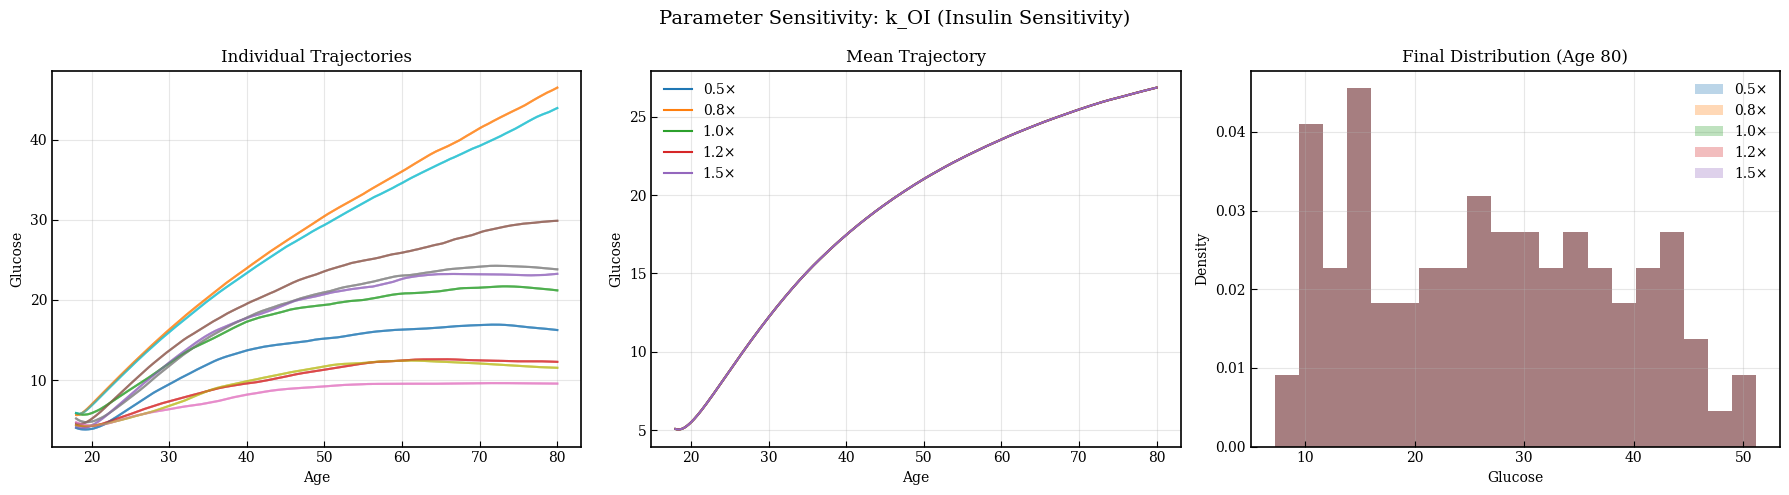

Saved: parameter sensitivity_20260514_215154.png


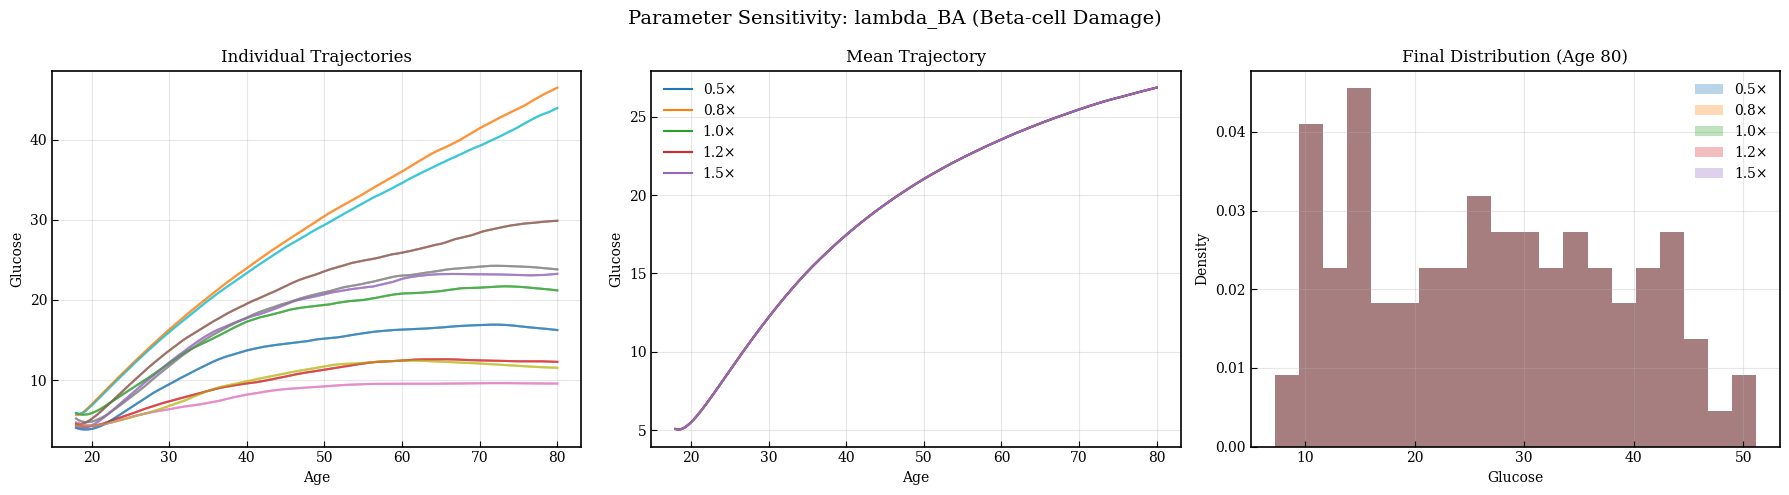

In [185]:
# =============================================================================
# PARAMETER SENSITIVITY ANALYSIS
# =============================================================================


# -------------------------------
# SETTINGS
# -------------------------------
scales = [0.5, 0.8, 1.0, 1.2, 1.5]
N_subset = 10  # for individual plots

# Choose ONE fixed setup (IMPORTANT)
init_states = init_distribution
behavior_mode = "dynamic"  # keep behavior fixed!
mvpa0 = vectorized_samples[:, -2]
cal0  = vectorized_samples[:, -1]

# -------------------------------
# MODIFIED SIMULATION (LOCAL WRAPPER)
# -------------------------------
def simulate_population_param(
    init_states, mvpa0, cal0, behavior_mode, key,
    param_name=None, scale=1.0
):

    key, subkey = jax.random.split(key)
    keys = jax.random.split(subkey, N_samples)

    def simulate_one(param_ind, init_ind, mvpa_i, cal_i, key_i):

        # --- behavior ---
        F_traj, Y_traj = generate_behavior_trajectories(
            t_span,
            mvpa_i,
            cal_i,
            behavior_mode,
            key_i
        )

        # --- base parameters ---
        base_params = dict(params_cases["Red"])

        for i, name in enumerate(theta_keys):
            base_params[name] = param_ind[i]

        # APPLY PARAMETER SCALING HERE
        if param_name is not None:
            base_params[param_name] = base_params[param_name] * scale

        # --- scan ---
        def step(y, inputs):
            t, F_t, Y_t = inputs
            params_step = {**base_params, "F": F_t, "Y": Y_t}

            y_next, _ = ode_rhs_scan(
                y, t, param_ind, params_step, dt, init_ind
            )
            return y_next, y_next

        _, ys = jax.lax.scan(step, init_ind, (t_span, F_traj, Y_traj))
        return ys

    states = jax.vmap(simulate_one)(
        param_samples,
        init_states,
        mvpa0,
        cal0,
        keys
    )

    return states


# =============================================================================
# RUN SENSITIVITY FOR A PARAMETER
# =============================================================================

def run_sensitivity(param_name):

    results_param = {}

    for scale in scales:
        key_local = jax.random.PRNGKey(0)  # fixed seed for fairness

        states = simulate_population_param(
            init_states,
            mvpa0,
            cal0,
            behavior_mode,
            key_local,
            param_name=param_name,
            scale=scale
        )

        results_param[scale] = states
        print(f"{param_name} × {scale} done")

    return results_param


# =============================================================================
# RUN EXPERIMENTS
# =============================================================================

results_kOI = run_sensitivity("k_OI")          # insulin sensitivity
results_lambda = run_sensitivity("lambda_BA")  # beta-cell damage


# =============================================================================
# PLOTTING FUNCTION
# =============================================================================

def plot_sensitivity(results_param, param_name):

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # -------------------------------
    # 1. Individual trajectories
    # -------------------------------
    np.random.seed(0)
    sample_key = list(results_param.keys())[2]  # use baseline (1.0)
    G_base = results_param[sample_key][:, :, 0]

    idx_subset = np.random.choice(G_base.shape[0], size=N_subset, replace=False)

    for scale, states in results_param.items():
        G = states[:, :, 0]

        for i in idx_subset:
            axes[0].plot(t_span, G[i], alpha=0.3)

    axes[0].set_title("Individual Trajectories")
    axes[0].set_xlabel("Age")
    axes[0].set_ylabel("Glucose")
    axes[0].grid(True, alpha=0.3)

    # -------------------------------
    # 2. Mean trajectories
    # -------------------------------
    for scale, states in results_param.items():
        G = states[:, :, 0]
        mean = G.mean(axis=0)

        axes[1].plot(t_span, mean, label=f"{scale}×")

    axes[1].set_title("Mean Trajectory")
    axes[1].set_xlabel("Age")
    axes[1].set_ylabel("Glucose")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # -------------------------------
    # 3. Final distribution
    # -------------------------------
    for scale, states in results_param.items():
        G_final = np.array(states[:, -1, 0])

        axes[2].hist(
            G_final,
            bins=20,
            density=True,
            alpha=0.3,
            label=f"{scale}×"
        )

    axes[2].set_title("Final Distribution (Age 80)")
    axes[2].set_xlabel("Glucose")
    axes[2].set_ylabel("Density")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    # -------------------------------
    # Layout
    # -------------------------------
    plt.suptitle(f"Parameter Sensitivity: {param_name}", fontsize=14)
    plt.tight_layout()
    save_figure(fig,"parameter sensitivity")
    plt.show()


# =============================================================================
# PLOT RESULTS
# =============================================================================

plot_sensitivity(results_kOI, "k_OI (Insulin Sensitivity)")
plot_sensitivity(results_lambda, "lambda_BA (Beta-cell Damage)")